# Project Introduction

# Phnom Penh Property Listings — Exploratory Data Analysis

## Objective

The purpose of this EDA is to understand the characteristics of property
listings in Phnom Penh and investigate factors related to property prices.

The analysis focuses on:

- Property price
- Property size
- Price per square meter
- Bedrooms
- Bathrooms
- Unit floor
- Property type
- District
- Data source
- Missing values
- Outliers
- Relationships between property characteristics and price

## Load the Gold data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "../data/gold/property_listings.csv"
)

eda_df = df.copy()

In [2]:
eda_df.shape


(2673, 27)

In [3]:
eda_df.head()

,listing_id,source,source_listing_id,source_listing_code,url,title,description,listing_type,property_type,project_name,...,city,district,commune,address,location_text,latitude,longitude,listing_created_at,listing_updated_at,scraped_at
0,realestate.com.kh_246560,realestate.com.kh,246560,NaN,https://www.realestate.com.kh/new-developments...,RARE 1-Bedroom Condo | Sale | Time Square 2 | ...,Property type Condo Title Hard Title Property ...,sale,Condo,Time Square II,...,Phnom Penh,Toul Kork,Boeung Kak 1,"Boeung Kak 1, Toul Kork, Phnom Penh","Boeung Kak 1, Toul Kork, Phnom Penh",NaN,NaN,2024-10-28T15:59:53.026661+07:00,NaN,2026-08-05T04:26:18+00:00
1,realestate.com.kh_259255,realestate.com.kh,259255,NaN,https://www.realestate.com.kh/new-developments...,2-Bedroom Condo for Sale at Chipmong Parkland ...,Property type Condo Title Strata Title Propert...,sale,Condo,Chip Mong | Park Land TK Condo,...,Phnom Penh,Sen Sok,Phnom Penh Thmey,"Phnom Penh Thmey, Sen Sok, Phnom Penh","Phnom Penh Thmey, Sen Sok, Phnom Penh",NaN,NaN,2026-02-18T15:22:57.238626+07:00,NaN,2026-08-05T04:26:18+00:00
2,realestate.com.kh_248268,realestate.com.kh,248268,NaN,https://www.realestate.com.kh/new-developments...,Rare 3-Bedroom Condominium for sale Time Squar...,Property type Condo Title Strata Title Propert...,sale,Condo,Time Square 306,...,Phnom Penh,Boeung Keng Kang,BKK 1,", BKK 1, Boeng Keng Kang, Phnom Penh",", BKK 1, Boeng Keng Kang, Phnom Penh",NaN,NaN,2025-01-27T17:03:59.484763+07:00,NaN,2026-08-05T04:26:18+00:00
3,realestate.com.kh_255697,realestate.com.kh,255697,NaN,https://www.realestate.com.kh/new-developments...,1-Bedroom Condo for Resale at One Park Residence,Property type Condo Title Hard Title Property ...,sale,Condo,One Park,...,Phnom Penh,Daun Penh,Srah Chak,"Srah Chak, Daun Penh, Phnom Penh","Srah Chak, Daun Penh, Phnom Penh",NaN,NaN,2025-09-29T14:49:58.371647+07:00,NaN,2026-08-05T04:26:18+00:00
4,realestate.com.kh_247259,realestate.com.kh,247259,NaN,https://www.realestate.com.kh/new-developments...,Studio Condo for Sale | Tk Star Project,Property type Condo Property ID 247259 Origina...,sale,Condo,TK Star International,...,Phnom Penh,Toul Kork,Boeung Kak 1,", Boeung Kak 1, Toul Kork, Phnom Penh",", Boeung Kak 1, Toul Kork, Phnom Penh",NaN,NaN,2024-12-05T15:43:31.339570+07:00,NaN,2026-08-05T04:26:18+00:00


In [4]:
# check columns

eda_df.columns

Index(['listing_id', 'source', 'source_listing_id', 'source_listing_code',
       'url', 'title', 'description', 'listing_type', 'property_type',
       'project_name', 'price_usd', 'size_m2', 'price_per_m2', 'bedrooms',
       'bathrooms', 'unit_floor', 'building_total_floors', 'city', 'district',
       'commune', 'address', 'location_text', 'latitude', 'longitude',
       'listing_created_at', 'listing_updated_at', 'scraped_at'],
      dtype='str')

In [5]:
eda_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2673 entries, 0 to 2672
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   listing_id             2673 non-null   str    
 1   source                 2673 non-null   str    
 2   source_listing_id      2673 non-null   str    
 3   source_listing_code    982 non-null    str    
 4   url                    2673 non-null   str    
 5   title                  2673 non-null   str    
 6   description            2655 non-null   str    
 7   listing_type           2673 non-null   str    
 8   property_type          2673 non-null   str    
 9   project_name           439 non-null    str    
 10  price_usd              2673 non-null   float64
 11  size_m2                2673 non-null   float64
 12  price_per_m2           2673 non-null   float64
 13  bedrooms               2501 non-null   float64
 14  bathrooms              1960 non-null   float64
 15  unit_floor     

Check column types, non-missing values and total rows.

In [6]:
# check duplicate rows
eda_df.duplicated().sum()

np.int64(0)

In [7]:
eda_df.describe()

,price_usd,size_m2,price_per_m2,bedrooms,bathrooms,unit_floor,building_total_floors,latitude,longitude,listing_updated_at
count,2.673000e+03,2673.000000,2673.000000,2501.000000,1960.000000,2057.000000,32.000000,0.0,0.0,0.0
mean,1.708184e+05,80.224403,1888.936150,1.556977,1.541837,17.823529,31.156250,NaN,NaN,NaN
std,2.593639e+05,69.469563,937.472751,0.994209,0.831541,12.460774,9.968044,NaN,NaN,NaN
min,2.000000e+04,20.000000,303.950000,0.000000,1.000000,1.000000,12.000000,NaN,NaN,NaN
25%,6.200000e+04,43.000000,1250.000000,1.000000,1.000000,9.000000,25.000000,NaN,NaN,NaN
50%,9.500000e+04,60.000000,1622.220000,1.000000,1.000000,15.000000,27.500000,NaN,NaN,NaN
75%,1.800000e+05,91.000000,2283.460000,2.000000,2.000000,24.000000,40.000000,NaN,NaN,NaN
max,5.000000e+06,1100.000000,8919.530000,5.000000,6.000000,92.000000,49.000000,NaN,NaN,NaN


Get statistics for numerical columns such as mean, minimum, maximum and quartiles.

In [8]:
# describe object columns

eda_df.describe(include="object").T

C:\Users\Meng\AppData\Local\Temp\ipykernel_3264\1476579417.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  eda_df.describe(include="object").T


,count,unique,top,freq
listing_id,2673,2673,realestate.com.kh_246560,1
source,2673,6,realestate.com.kh,844
source_listing_id,2673,2673,246560,1
source_listing_code,982,978,S1468168,2
url,2673,2673,https://www.realestate.com.kh/new-developments...,1
title,2673,2459,Unit for sale,19
description,2655,2616,LZ Sea View is a premier residential project i...,5
listing_type,2673,2,sale,2500
property_type,2673,2,Condo,2482
project_name,439,75,Urban Village Phase 2,59


Understand categorical/text columns such as source, district and property type.

## Check Missing Values

In [9]:
missing = pd.DataFrame({
    "missing_count": eda_df.isnull().sum(),
    "missing_percent": eda_df.isnull().mean() * 100
})

missing.sort_values(
    "missing_percent",
    ascending=False
)

,missing_count,missing_percent
latitude,2673,100.000000
listing_updated_at,2673,100.000000
longitude,2673,100.000000
building_total_floors,2641,98.802843
project_name,2234,83.576506
address,1736,64.945754
source_listing_code,1691,63.262252
commune,1073,40.142162
bathrooms,713,26.674149
unit_floor,616,23.045267


## Remove Completely Empty Columns From EDA

In [10]:
eda_df = eda_df.drop(
    columns=[
        "latitude",
        "longitude",
        "listing_updated_at",
        "building_total_floors",
        "project_name",
        "source_listing_code"
    ]
)

address 64.9% missing can still help you validate suspicious listings. Keep address as supporting information, but don't make it one of your main statistical variables.

## Convert Date Columns

In [11]:
eda_df["listing_created_at"] = pd.to_datetime(
    eda_df["listing_created_at"],
    errors="coerce"
)

eda_df["scraped_at"] = pd.to_datetime(
    eda_df["scraped_at"],
    errors="coerce"
)

In [12]:
eda_df.dtypes

listing_id                                  str
source                                      str
source_listing_id                           str
url                                         str
title                                       str
description                                 str
listing_type                                str
property_type                               str
price_usd                               float64
size_m2                                 float64
price_per_m2                            float64
bedrooms                                float64
bathrooms                               float64
unit_floor                              float64
city                                        str
district                                    str
commune                                     str
address                                     str
location_text                               str
listing_created_at    datetime64[us, UTC+07:00]
scraped_at                  datetime64[u

# Check Categorical Values

In [13]:
# For property_type

eda_df["property_type"].value_counts(dropna=False)

property_type
Condo        2482
Penthouse     191
Name: count, dtype: int64

In [14]:
# For listing_type
eda_df["listing_type"].value_counts(dropna=False)

listing_type
sale         2500
sale/rent     173
Name: count, dtype: int64

In [15]:
# For City
    
eda_df["city"].value_counts(dropna=False)

city
Phnom Penh    2673
Name: count, dtype: int64

## Check District Values

In [16]:
eda_df["district"].value_counts(dropna=False)

district
Boeung Keng Kang    559
Meanchey            416
NaN                 411
Chamkarmon          298
Toul Kork           295
Sen Sok             233
Chroy Changvar      201
Chbar Ampov          92
Daun Penh            69
Prampi Makara        49
Russey Keo           42
Pur Senchey           8
Name: count, dtype: int64

This is much more useful than city.

Later we can ask:

Which district has the highest property price?

And:

Which district has the highest price per square meter?

## Check Commune Consistency

In [17]:
eda_df["commune"].value_counts(dropna=False).head(30)

commune
NaN                   1073
Tonle Bassac           158
Chak Angrae Leu        157
Bkk1                   122
Boeung Kak I           117
BKK 1                  104
Chroy Chongva           97
Chroy Changvar          89
Boeung Tumpun           70
Nirouth                 59
Tuek Thla               50
Boeung Kak 1            46
Phnom Penh              45
Phnom Penh Thmey        42
Veal Vong               40
BKK 3                   36
Phnom Penh Thmei        28
Boeung Kak 2            24
Bkk3                    24
Boeung Trabek           23
Srah Chak               19
Boeung Trobaek          19
Ou Baek K'am            17
Stueng Mean Chey I      16
Boeng Tompun I          15
Wat Phnom               14
Boeung Kak Ii           12
Tuol Sangkae 2          10
Tuol Tompoung 1          9
Chamkarmon               9
Name: count, dtype: int64

## Check Price Per m² Formula

In [18]:
eda_df["calculated_price_per_m2"] = (
    eda_df["price_usd"] / eda_df["size_m2"]
)

In [19]:
(
    eda_df["price_per_m2"]
    - eda_df["calculated_price_per_m2"]
).abs().describe()

count    2673.000000
mean        0.002092
std         0.001580
min         0.000000
25%         0.000476
50%         0.002174
75%         0.003333
max         0.005000
dtype: float64

For your dataset, the values are almost identical.

The largest difference is only around:

0.005

That's simply rounding.

Therefore:

price_per_m2 is calculated correctly.

In [20]:
eda_df.drop(
    columns="calculated_price_per_m2",
    inplace=True
)

## Descriptive Statistics

In [21]:
# Numeric Columns Description

numeric_cols = [
    "price_usd",
    "size_m2",
    "price_per_m2",
    "bedrooms",
    "bathrooms",
    "unit_floor"
]

eda_df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
price_usd,2673.0,170818.361766,259363.900292,20000.00,62000.0,95000.00,180000.00,5000000.00
size_m2,2673.0,80.224403,69.469563,20.00,43.0,60.00,91.00,1100.00
price_per_m2,2673.0,1888.936150,937.472751,303.95,1250.0,1622.22,2283.46,8919.53
bedrooms,2501.0,1.556977,0.994209,0.00,1.0,1.00,2.00,5.00
bathrooms,1960.0,1.541837,0.831541,1.00,1.0,1.00,2.00,6.00
unit_floor,2057.0,17.823529,12.460774,1.00,9.0,15.00,24.00,92.00


### Mean vs Median

For price:

Mean   = $170,818
Median = $95,000

That's a big difference.

Why?

Because expensive properties such as:

$1M
$2M
$3M
$5M

pull the mean upward.

So price distribution is probably:

Right-skewed.


## PART 2 — UNIVARIATE ANALYSIS
What is Univariate Analysis?

"Uni" means one.

We analyze one variable at a time.

For example:

Price only
Bedroom only
Floor only
District only

We want to understand:

distribution
typical value
minimum
maximum
unusual values

## Analyze Property Price

In [22]:
eda_df["log_price_usd"] = np.log1p(
    eda_df["price_usd"]
)


eda_df[
    [
        "price_usd",
        "log_price_usd"
    ]
].head()

,price_usd,log_price_usd
0,74000.0,11.211834
1,97000.0,11.482477
2,300000.0,12.611541
3,175000.0,12.072547
4,53000.0,10.878066


In [23]:
print(
    "Original price skewness:",
    eda_df["price_usd"].skew()
)

print(
    "Log price skewness:",
    eda_df["log_price_usd"].skew()
)

Original price skewness: 6.8820788477927115
Log price skewness: 0.9611313233338742


The original price_usd distribution was highly right-skewed, with a skewness value of 6.88. This was caused by a relatively small number of high-priced luxury properties. After applying a logarithmic transformation, the skewness decreased to 0.96. This indicates that the transformation substantially reduced the effect of extreme values and produced a more balanced distribution, while retaining all property listings.

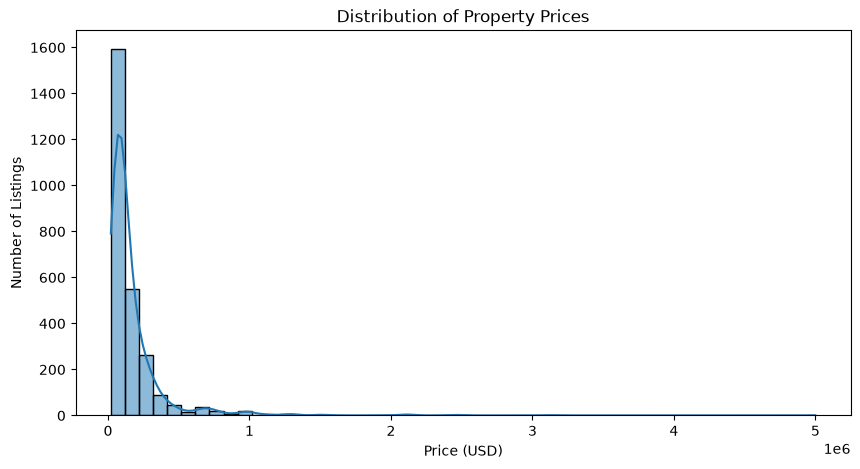

In [24]:
# Histogram of price_usd

plt.figure(figsize=(10, 5))

sns.histplot(
    data=eda_df,
    kde=True,
    x="price_usd",
    bins=50
)

plt.title("Distribution of Property Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Listings")

plt.show()

"The distribution is strongly right-skewed because a small number of very expensive properties extend the upper tail."

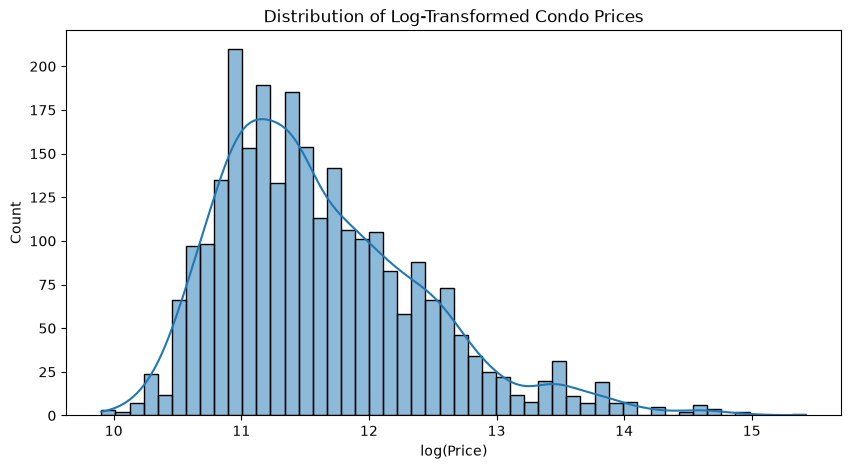

In [25]:
# Log Transformation of price_usd

plt.figure(figsize=(10, 5))

sns.histplot(
    data=eda_df,
    kde=True,
    x="log_price_usd",
    bins=50,
)

plt.xlabel("log(Price)")
plt.ylabel("Count")
plt.title("Distribution of Log-Transformed Condo Prices")

plt.show()

### Why did log_transform price?

“The original property prices were strongly right-skewed because a small number of luxury listings had very high prices. I applied a log transformation to compress those extreme values and reduce skewness. This makes the distribution easier to analyze without deleting valid expensive properties.”

“The original property-price distribution was strongly right-skewed because of a small number of high-priced luxury properties. A logarithmic transformation was applied to reduce the skewness and compress extreme values, making the overall distribution easier to visualize and analyze.”

## Price Box Plot

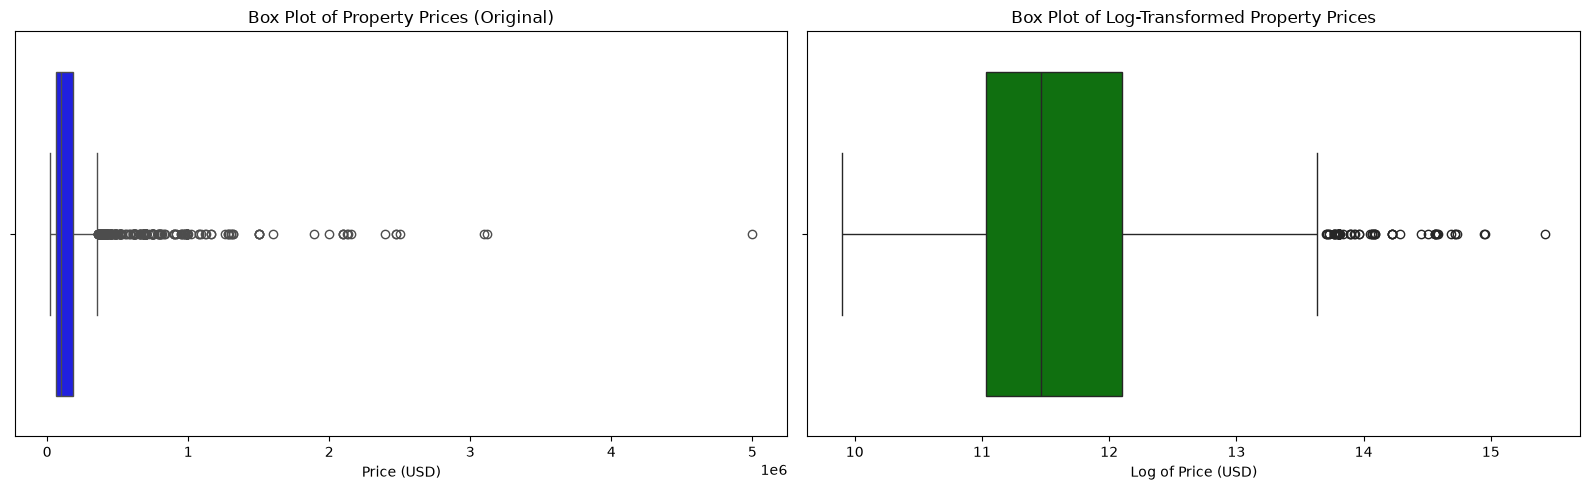

In [26]:
# Set up a side-by-side box plot layout
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left Box Plot: Original Price ---
sns.boxplot(
    data=eda_df,
    x="price_usd",
    color="blue",
    ax=axes[0]
)
axes[0].set_title("Box Plot of Property Prices (Original)")
axes[0].set_xlabel("Price (USD)")

# --- Right Box Plot: Log-Transformed Price ---
sns.boxplot(
    data=eda_df,
    x="log_price_usd",
    color="green",
    ax=axes[1]
)
axes[1].set_title("Box Plot of Log-Transformed Property Prices")
axes[1].set_xlabel("Log of Price (USD)")

plt.tight_layout()
plt.show()


Right Box Plot:
The original property-price distribution is strongly right-skewed. Most properties are concentrated in a relatively lower price range, while many high-priced properties appear as outliers on the right. These extreme values stretch the scale and make the central part of the distribution difficult to see.


Left Box Plot (log):
After log transformation, the distribution becomes much more balanced. The extreme high-price values are compressed, so the middle 50% of the data is easier to observe. Some high-value observations still appear as outliers, but their influence on the scale is much smaller.



The original property-price box plot shows a strongly right-skewed distribution, with the central 50% of prices compressed near the lower end and many high-priced properties appearing as statistical outliers. After applying a logarithmic transformation, the extreme prices are compressed and the distribution becomes much more balanced. The log transformation does not remove high-priced listings; it only reduces their influence on the scale. Some outliers remain, indicating that a small number of properties are still substantially more expensive than most listings.

## Analyze Size

In [27]:
eda_df["size_m2"].describe()

count    2673.000000
mean       80.224403
std        69.469563
min        20.000000
25%        43.000000
50%        60.000000
75%        91.000000
max      1100.000000
Name: size_m2, dtype: float64

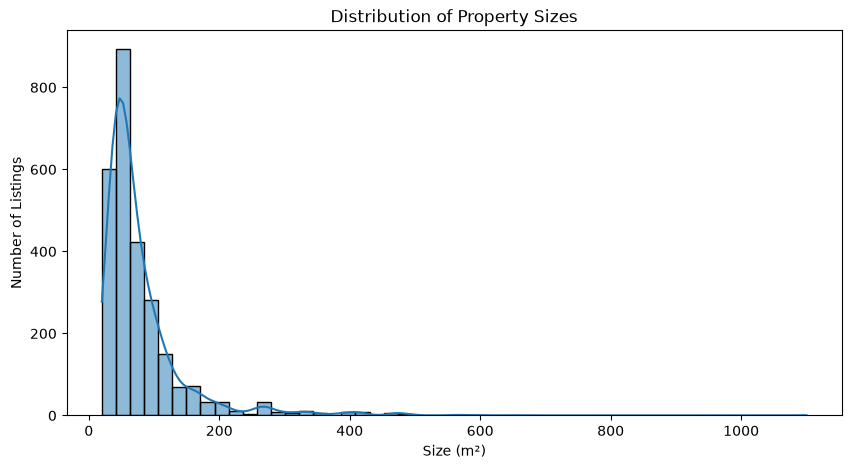

In [28]:
# Histogram of Size_m2
plt.figure(figsize=(10, 5))

sns.histplot(
    data=eda_df,
    kde=True,
    x="size_m2",
    bins=50
)

plt.title("Distribution of Property Sizes")
plt.xlabel("Size (m²)")
plt.ylabel("Number of Listings")

plt.show()

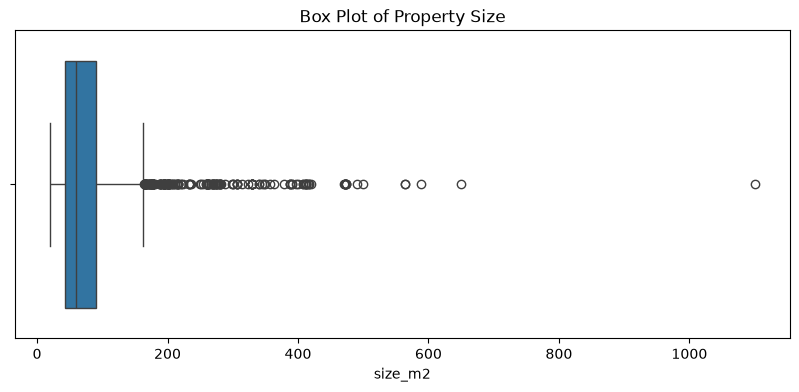

In [29]:
# Box Plot of Size_m2

plt.figure(figsize=(10, 4))

sns.boxplot(
    data=eda_df,
    x="size_m2"
)

plt.title("Box Plot of Property Size")

plt.show()

## Bedroom Analysis

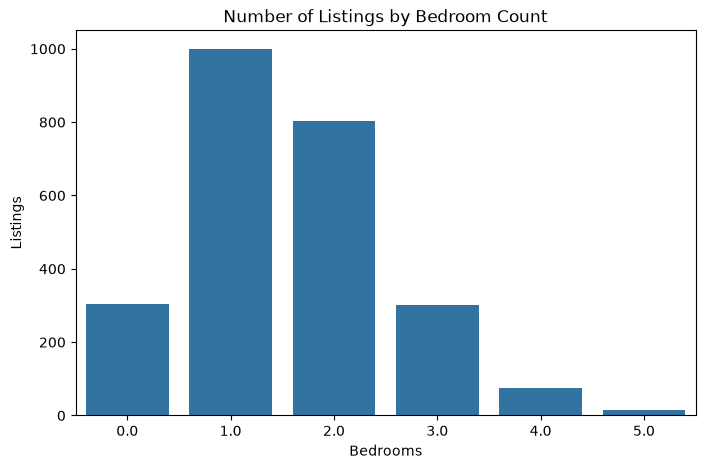

In [30]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=eda_df,
    x="bedrooms"
)

plt.title("Number of Listings by Bedroom Count")
plt.xlabel("Bedrooms")
plt.ylabel("Listings")

plt.show()

In [31]:
eda_df["bedrooms"].value_counts().sort_index()

bedrooms
0.0     304
1.0    1000
2.0     804
3.0     302
4.0      75
5.0      16
Name: count, dtype: int64

bedrooms ranging:

0 → 5

Is 0 bedroom wrong?

Not necessarily.

0 bedrooms

often means:

Studio apartment.

So don't remove 0 automatically.

## Bathroom Analysis

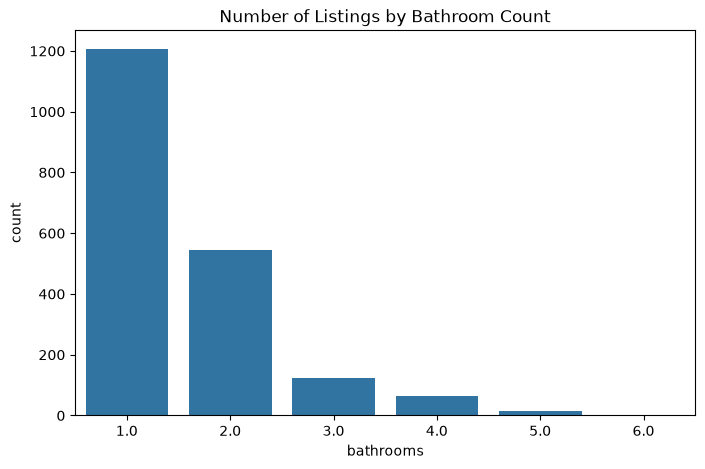

In [32]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=eda_df,
    x="bathrooms"
)

plt.title("Number of Listings by Bathroom Count")

plt.show()

In [33]:
eda_df["bathrooms"].value_counts().sort_index()

bathrooms
1.0    1207
2.0     546
3.0     125
4.0      65
5.0      14
6.0       3
Name: count, dtype: int64

## Floor Analysis

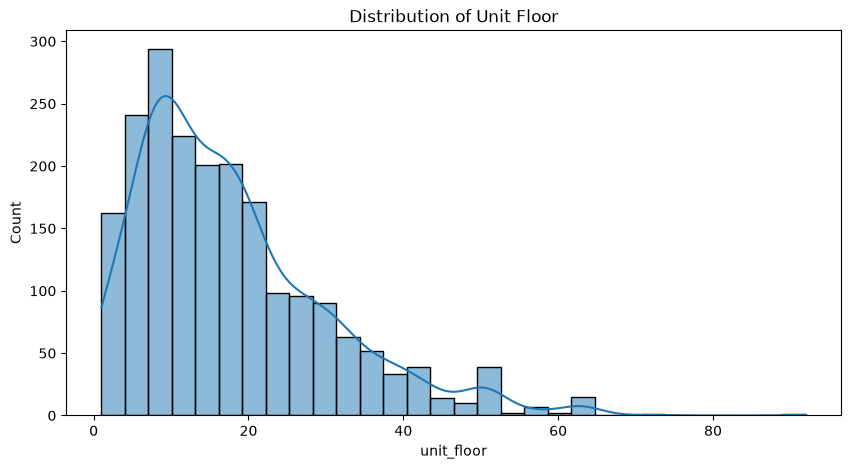

In [34]:
# Histogram of Unit Floor

plt.figure(figsize=(10, 5))

sns.histplot(
    data=eda_df,
    kde=True,
    x="unit_floor",
    bins=30
)

plt.title("Distribution of Unit Floor")

plt.show()

In [35]:
eda_df["unit_floor"].describe()

count    2057.000000
mean       17.823529
std        12.460774
min         1.000000
25%         9.000000
50%        15.000000
75%        24.000000
max        92.000000
Name: unit_floor, dtype: float64

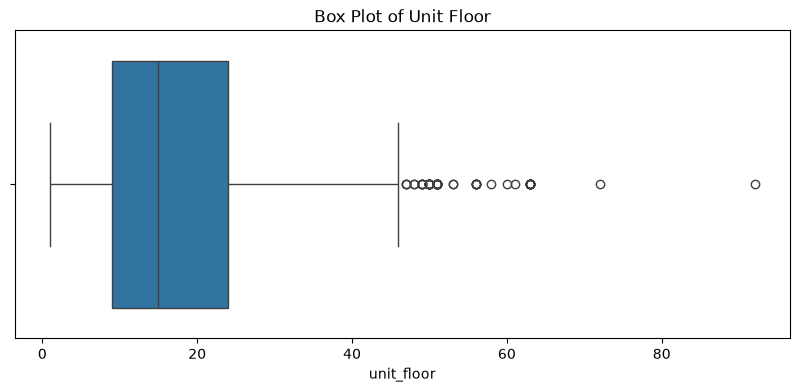

In [36]:
# Box Plot of Size_m2

plt.figure(figsize=(10, 4))

sns.boxplot(
    data=eda_df,
    x="unit_floor"
)

plt.title("Box Plot of Unit Floor")

plt.show()

## Price_Per_m2

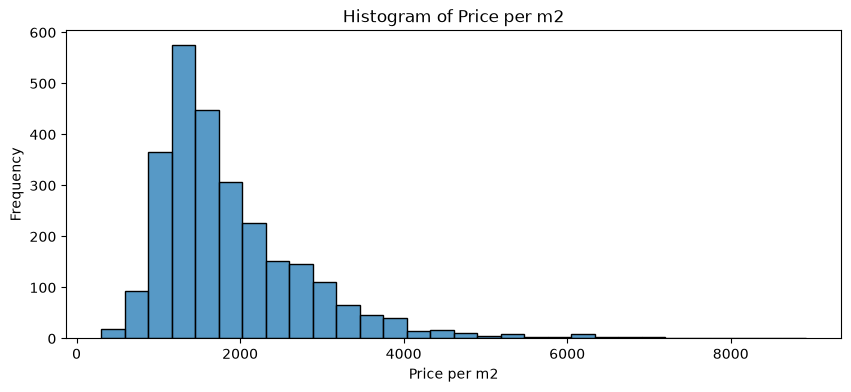

In [37]:
# Histogram of price_per_m2

plt.figure(figsize=(10, 4))
sns.histplot(eda_df["price_per_m2"].dropna(), bins=30)
plt.title("Histogram of Price per m2")
plt.xlabel("Price per m2")
plt.ylabel("Frequency")
plt.show()


In [38]:
eda_df["price_per_m2"].describe()

count    2673.000000
mean     1888.936150
std       937.472751
min       303.950000
25%      1250.000000
50%      1622.220000
75%      2283.460000
max      8919.530000
Name: price_per_m2, dtype: float64

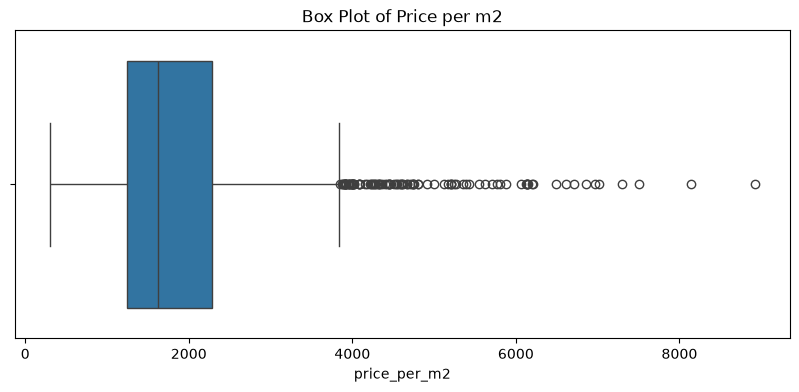

In [39]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=eda_df,
    x="price_per_m2"
)

plt.title("Box Plot of Price per m2")

plt.show()


## PART 3 — OUTLIER ANALYSIS

## Create a clean working copy

In [40]:
clean_df = eda_df.copy()

From now on:

. eda_df = dataset you explored

. clean_df = dataset where you will correct/remove confirmed errors

## Check outliers for the important numerical columns

In [41]:
numeric_check = [
    "price_usd",
    "size_m2",
    "price_per_m2",
    "bedrooms",
    "bathrooms",
    "unit_floor"
]

In [42]:
def find_outliers(df, column):
    data = df[column].dropna()

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"Column: {column}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower bound: {lower_bound}")
    print(f"Upper bound: {upper_bound}")
    print(f"Number of outliers: {len(outliers)}")

    return outliers

## Start with Price

In [43]:
price_outliers = find_outliers(
    clean_df,
    "price_usd"
)

Column: price_usd
Q1: 62000.0
Q3: 180000.0
IQR: 118000.0
Lower bound: -115000.0
Upper bound: 357000.0
Number of outliers: 224


There are about:

224

properties above the IQR boundary.

That does not mean 224 properties should be deleted.

Many may simply be:

penthouses, 
large units, 
premium locations, 
luxury developments.

In [44]:
price_outliers[
    [
        "listing_id",
        "title",
        "property_type",
        "price_usd",
        "size_m2",
        "price_per_m2",
        "bedrooms",
        "district",
        "source",
        "url"
    ]
].sort_values(
    "price_usd",
    ascending=False
).head(5)

,listing_id,title,property_type,price_usd,size_m2,price_per_m2,bedrooms,district,source,url
2665,harbor-property.com_86231,"Condo for Sale, Tonle Bassac, $5000000_5Bedroo...",Penthouse,5000000.0,1100.00,4545.45,5.0,Chamkarmon,harbor-property.com,https://www.harbor-property.com/house/detail/8...
2668,camrealtyservice.com_sky-villa-for-sale-in-mor...,45th Floor 5 Bedroom Sky Villa For Sale in Mor...,Penthouse,3121250.0,471.66,6617.58,5.0,NaN,camrealtyservice.com,https://camrealtyservice.com/property/sky-vill...
2666,camrealtyservice.com_36th-floor-luxurious-4-be...,36th Floor Luxurious 4 Bedroom Penthouse For S...,Penthouse,3100000.0,588.00,5272.11,4.0,Chamkarmon,camrealtyservice.com,https://camrealtyservice.com/property/36th-flo...
2669,camrealtyservice.com_duplex-condo-for-sale-the...,25th Floor 3 Bedroom Duplex Condo For Sale The...,Penthouse,2500000.0,412.00,6067.96,3.0,NaN,camrealtyservice.com,https://camrealtyservice.com/property/duplex-c...
2660,harbor-property.com_96084,"Condo for Sale, Tonle Bassac, $2470000_4Bedroo...",Penthouse,2470000.0,474.00,5210.97,4.0,Chamkarmon,harbor-property.com,https://www.harbor-property.com/house/detail/9...


## Check Size Outliers

In [45]:
size_outliers = find_outliers(
    clean_df,
    "size_m2"
)

Column: size_m2
Q1: 43.0
Q3: 91.0
IQR: 48.0
Lower bound: -29.0
Upper bound: 163.0
Number of outliers: 201


In [46]:
size_outliers[
    [
        "title",
        "property_type",
        "size_m2",
        "price_usd",
        "bedrooms",
        "bathrooms",
        "district",
        "source"
    ]
].sort_values(
    "size_m2",
    ascending=False
).head(5)

,title,property_type,size_m2,price_usd,bedrooms,bathrooms,district,source
2665,"Condo for Sale, Tonle Bassac, $5000000_5Bedroo...",Penthouse,1100.00,5000000.0,5.0,5.0,Chamkarmon,harbor-property.com
2671,Penthouse 4 Bedroom Condo For Sale - De Castle...,Penthouse,650.00,1500000.0,4.0,NaN,Boeung Keng Kang,aps.com.kh
2666,36th Floor Luxurious 4 Bedroom Penthouse For S...,Penthouse,588.00,3100000.0,4.0,5.0,Chamkarmon,camrealtyservice.com
2657,[Fully Furnished] 4-BR Penthouse of 564 Sq.m. ...,Penthouse,564.00,2395000.0,4.0,NaN,Daun Penh,khpropertyhub.com
2662,"Condo for Sale, Phsar Thmey I, $2000000_4Bedro...",Condo,563.75,2000000.0,4.0,5.0,NaN,harbor-property.com


Ask:

Is a 500–1,100 m² property really possible?

A penthouse could be huge.

A normal 1-bedroom condo reported as 1,100 m² would be much more suspicious.

## Check Bedrooms

In [47]:
bedroom_outliers = find_outliers(
    clean_df,
    "bedrooms"
)

Column: bedrooms
Q1: 1.0
Q3: 2.0
IQR: 1.0
Lower bound: -0.5
Upper bound: 3.5
Number of outliers: 91


Therefore:

4 bedrooms
5 bedrooms

are technically outliers.

But are they wrong?

No.

A 4-bedroom penthouse is completely possible.

This demonstrates why:

IQR detects unusual values, not incorrect values.

In [48]:
bedroom_outliers[
    [
        "title",
        "bedrooms",
        "property_type",
        "size_m2",
        "price_usd",
        "description"
    ]
].sort_values(
    "bedrooms",
    ascending=False
).head(5)

,title,bedrooms,property_type,size_m2,price_usd,description
114,DUPLEX FIVE BEDROOMS CONDO FOR SALE/RENT IN OR...,5.0,Condo,379.00,450000.0,Property type Condo Title Strata Title Propert...
757,Spacious Riverview Penthouse for Sale,5.0,Penthouse,220.00,285978.0,Property type Penthouse Title Hard Title Prope...
2661,"Condo for Sale, BKK1, $2153387_5Bedroom_306.86m²",5.0,Penthouse,306.86,2153387.0,Condo for sale 公寓出售 Property code: ACD26-039 P...
2668,45th Floor 5 Bedroom Sky Villa For Sale in Mor...,5.0,Penthouse,471.66,3121250.0,45th Floor 5 Bedroom Sky Villa For Sale in Mor...
2667,Duplex 5 Bedroom Penthouse For Sale in Picasso...,5.0,Penthouse,306.86,2136378.0,Duplex 5 Bedroom Penthouse For Sale in Picasso...


Important:

4 bedrooms
5 bedrooms

may be statistical outliers but still completely valid.

Also:

0 bedrooms

may mean:

Studio apartment.

So don't remove them automatically.

## Check Bathrooms

In [49]:
bathroom_outliers = find_outliers(
    clean_df,
    "bathrooms"
)

Column: bathrooms
Q1: 1.0
Q3: 2.0
IQR: 1.0
Lower bound: -0.5
Upper bound: 3.5
Number of outliers: 82


Therefore:

4,
5,
6

bathrooms are flagged.

Again, they may be valid luxury properties.

In [50]:
bathroom_outliers[
    [
        "title",
        "bedrooms",
        "bathrooms",
        "size_m2",
        "property_type",
        "description"
    ]
].sort_values(
    "bathrooms",
    ascending=False
).head(5)

,title,bedrooms,bathrooms,size_m2,property_type,description
114,DUPLEX FIVE BEDROOMS CONDO FOR SALE/RENT IN OR...,5.0,6.0,379.00,Condo,Property type Condo Title Strata Title Propert...
2668,45th Floor 5 Bedroom Sky Villa For Sale in Mor...,5.0,6.0,471.66,Penthouse,45th Floor 5 Bedroom Sky Villa For Sale in Mor...
2441,32nd Floor 5 Bedroom Duplex Penthouse For Sale...,5.0,6.0,412.49,Penthouse,32nd Floor 5 Bedroom Duplex Penthouse For Sale...
2027,"Condo for Sale, BKK1, $1600000_4Bedroom",4.0,5.0,411.58,Condo,🎯 Picasso City Garden Unit: 26L 🛌 4+1 bed 4bat...
837,J Tower 3 : Tallest Residential Highrise in Ph...,3.0,5.0,166.00,Condo,Main Category House & Land Category Condo For ...


For example:

5-bedroom penthouse
6 bathrooms

could make sense.

But:

Studio
6 bathrooms

would deserve investigation.

## Check Floor

In [51]:
floor_outliers = find_outliers(
    clean_df,
    "unit_floor"
)

Column: unit_floor
Q1: 9.0
Q3: 24.0
IQR: 15.0
Lower bound: -13.5
Upper bound: 46.5
Number of outliers: 77


In [52]:
floor_outliers[
    [
        "title",
        "unit_floor",
        "property_type",
        "project_name" if "project_name" in clean_df.columns else "district",
        "description",
        "source"
    ]
].sort_values(
    "unit_floor",
    ascending=False
).head(5)

,title,unit_floor,property_type,district,description,source
1704,"Condo for Sale, Boeung Kak I, $78000_1Bedroom_...",92.0,Condo,Toul Kork,Click to view details of Condo for Sale in Boe...,harbor-property.com
1177,Rare High-Ceiling 3BR Unit on 72nd Floor with ...,72.0,Condo,Chamkarmon,Phnom Penh's Rare High-Ceiling Unit | 72F Inco...,khpropertyhub.com
2598,Presale 2 Bedroom For Sale (Type B2) - Le Cond...,63.0,Condo,Boeung Keng Kang,The 2‑Bedroom Residence at Le Condé 2 presents...,aps.com.kh
2599,Presale 3 Bedroom For Sale (Type C4) - Le Cond...,63.0,Condo,Boeung Keng Kang,"The 3‑Bedroom, 2‑Bathroom Residence at Le Cond...",aps.com.kh
2602,Presale 3 Bedroom For Sale (Type C1) - Le Cond...,63.0,Condo,Boeung Keng Kang,The 3‑Bedroom Residence at Le Condé 2 offers a...,aps.com.kh


In [53]:
clean_df.loc[
    clean_df["listing_id"] == "harbor-property.com_113571",
    "unit_floor"
] = np.nan

## Check price_per_m2

In [54]:
ppm2_outliers = find_outliers(
    clean_df,
    "price_per_m2"
)

Column: price_per_m2
Q1: 1250.0
Q3: 2283.46
IQR: 1033.46
Lower bound: -300.19000000000005
Upper bound: 3833.65
Number of outliers: 104


In [55]:
ppm2_outliers[
    [
        "title",
        "price_usd",
        "size_m2",
        "price_per_m2",
        "unit_floor",
        "property_type",
        "district",
        "source"
    ]
].sort_values(
    "price_per_m2",
    ascending=False
).head(5)

,title,price_usd,size_m2,price_per_m2,unit_floor,property_type,district,source
1703,"Condo for Sale, BKK1, $285425_4Bedroom_32m²",285425.0,32.00,8919.53,33.0,Condo,Boeung Keng Kang,harbor-property.com
1707,"Condo for Sale, Chroy Chongva, $228000_2Bedroo...",228000.0,28.00,8142.86,28.0,Condo,NaN,harbor-property.com
1986,"Condo for Sale, Boeung Kak II, $150000_2Bedroo...",150000.0,20.00,7500.00,NaN,Condo,Toul Kork,harbor-property.com
1985,"Condo for Sale, Phnom Penh, $270000_2Bedroom_37m²",270000.0,37.00,7297.30,20.0,Condo,NaN,harbor-property.com
2661,"Condo for Sale, BKK1, $2153387_5Bedroom_306.86m²",2153387.0,306.86,7017.49,26.0,Penthouse,Boeung Keng Kang,harbor-property.com


In [56]:
print("Before cleaning:", eda_df.shape)
print("After cleaning:", clean_df.shape)

Before cleaning: (2673, 22)
After cleaning: (2673, 22)


In [57]:
clean_df[
    [
        "price_usd",
        "size_m2",
        "price_per_m2",
        "bedrooms",
        "bathrooms",
        "unit_floor"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
price_usd,2673.0,170818.361766,259363.900292,20000.00,62000.0,95000.00,180000.00,5000000.00
size_m2,2673.0,80.224403,69.469563,20.00,43.0,60.00,91.00,1100.00
price_per_m2,2673.0,1888.936150,937.472751,303.95,1250.0,1622.22,2283.46,8919.53
bedrooms,2501.0,1.556977,0.994209,0.00,1.0,1.00,2.00,5.00
bathrooms,1960.0,1.541837,0.831541,1.00,1.0,1.00,2.00,6.00
unit_floor,2056.0,17.787451,12.355877,1.00,9.0,15.00,24.00,72.00


I change only one because the total floor has only 49 but the unit floor they set 92 and no more accual evidence so I change unit_floor = 92 to nan

For example:

“Statistical outliers were inspected using property titles, descriptions, sizes, property types, and source information. Valid luxury properties were retained, while confirmed parsing errors were corrected or set to missing.”

That's a strong methodology explanation.

## PART 4 — CATEGORICAL ANALYSIS

## Analyze Property Type

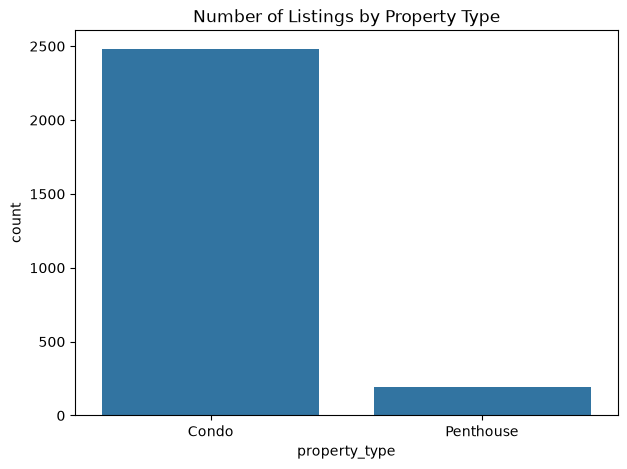

In [58]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=clean_df,
    x="property_type"
)

plt.title("Number of Listings by Property Type")

plt.show()

## Source Website

In [59]:
clean_df["source"].value_counts()

source
realestate.com.kh       844
harbor-property.com     753
khpropertyhub.com       675
camrealtyservice.com    199
aps.com.kh              109
khmer24.com              93
Name: count, dtype: int64

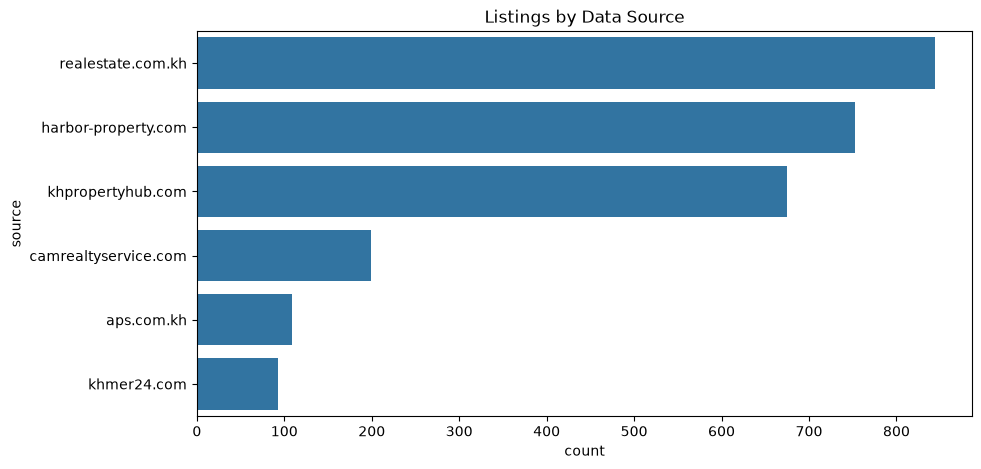

In [60]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=clean_df,
    y="source",
    order=clean_df["source"].value_counts().index
)

plt.title("Listings by Data Source")

plt.show()

The listings are collected from multiple property websites, but the number of records differs by source. Therefore, websites with more listings can have a greater influence on the overall EDA results.

## PART 5 — BIVARIATE ANALYSIS

## Size vs Price

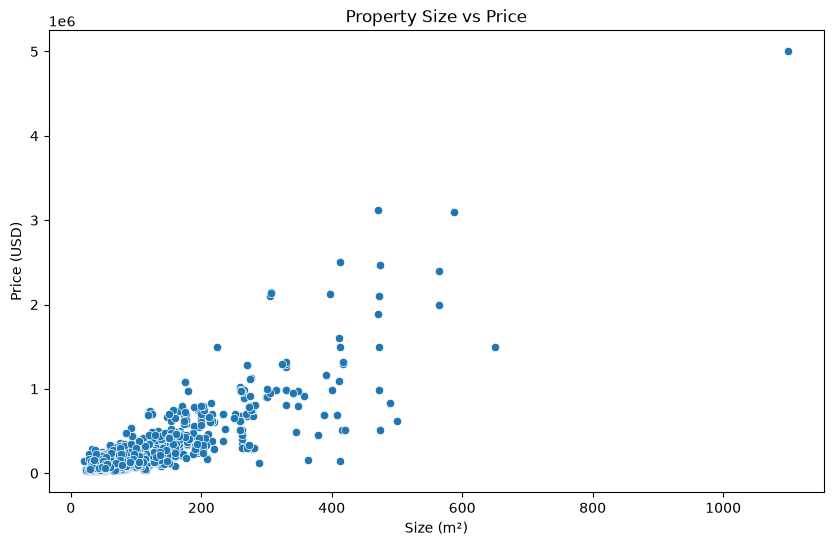

In [61]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=eda_df,
    x="size_m2",
    y="price_usd"
)

plt.title("Property Size vs Price")
plt.xlabel("Size (m²)")
plt.ylabel("Price (USD)")

plt.show()

Interpretation: The scatter plot shows a clear positive relationship between property size and price. Larger properties generally have higher selling prices, although some properties are considerably more expensive than others of similar size.

## Bedrooms vs Price

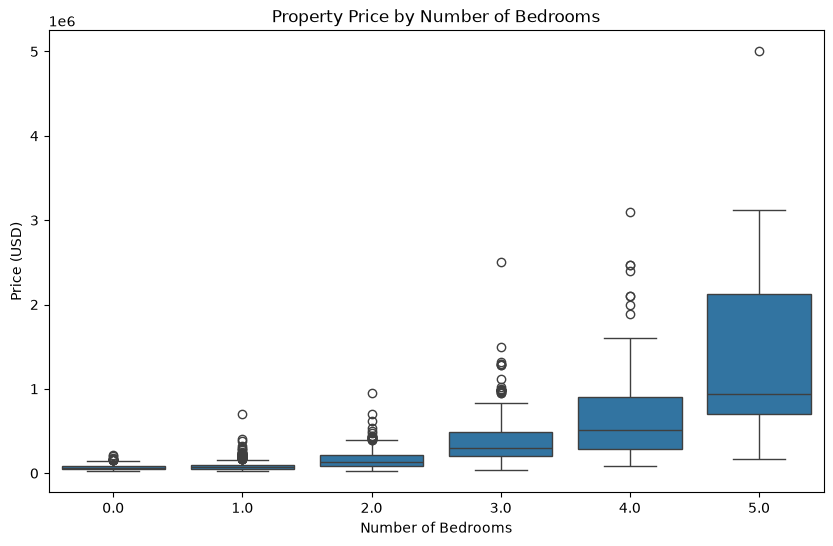

In [62]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=clean_df,
    x="bedrooms",
    y="price_usd"
)

plt.title("Property Price by Number of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price (USD)")

plt.show()

## Calculate median price by bedroom

In [63]:
bedroom_price = (
    clean_df
    .groupby("bedrooms")
    .agg(
        listings=("price_usd", "count"),
        median_price=("price_usd", "median")
    )
)

bedroom_price

,listings,median_price
bedrooms,,
0.0,304,60000.0
1.0,1000,70000.0
2.0,804,135000.0
3.0,302,300000.0
4.0,75,515000.0
5.0,16,937500.0


Interpretation: Median property prices generally increase as the number of bedrooms increases. However, larger-bedroom properties are also typically larger in size, so bedroom count alone may not be responsible for the higher prices.

## Bathrooms vs Price

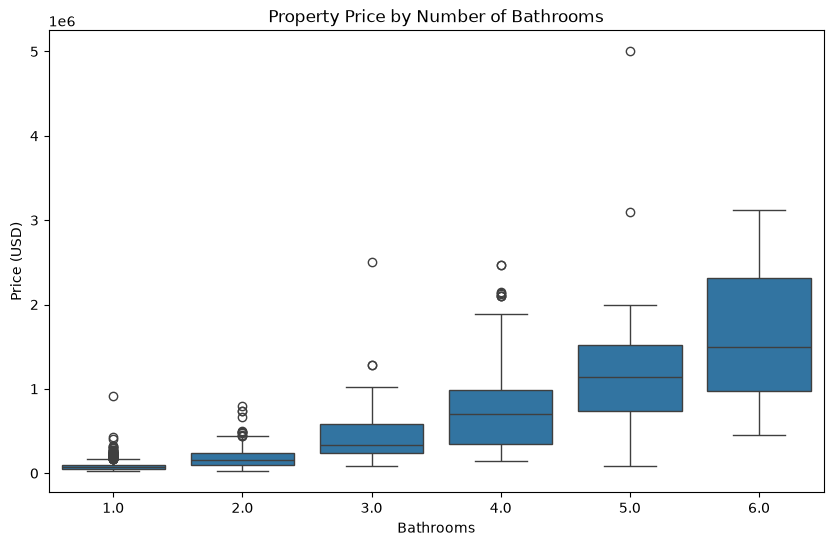

In [64]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=clean_df,
    x="bathrooms",
    y="price_usd"
)


plt.title("Property Price by Number of Bathrooms")
plt.xlabel("Bathrooms")
plt.ylabel("Price (USD)")

plt.show()

## Calculate median prices

In [65]:
bathroom_price = (
    clean_df
    .groupby("bathrooms")
    .agg(
        listings=("price_usd", "count"),
        median_price=("price_usd", "median")
    )
)

bathroom_price

,listings,median_price
bathrooms,,
1.0,1207,70000.0
2.0,546,162000.0
3.0,125,330000.0
4.0,65,700000.0
5.0,14,1142419.0
6.0,3,1500000.0


Interpretation: Properties with more bathrooms tend to have higher median prices. However, categories with five or six bathrooms contain very few listings, so those values should be interpreted cautiously.

## Unit Floor vs Price

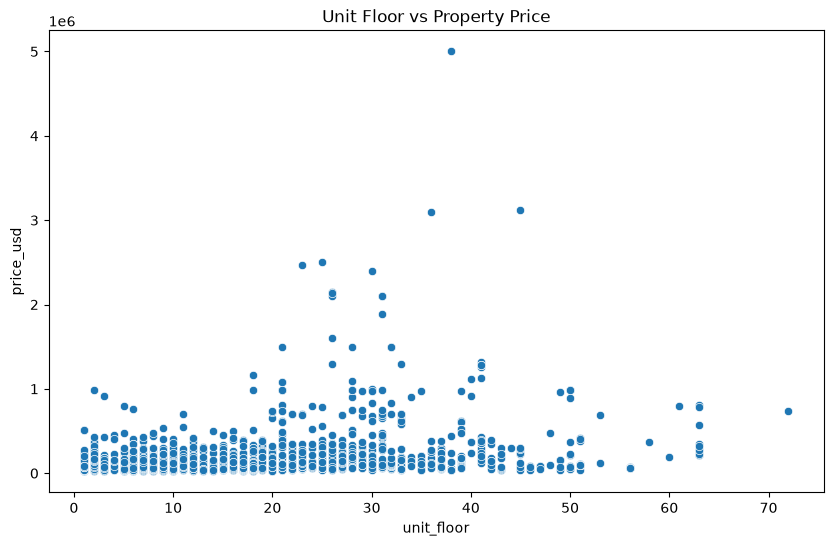

In [66]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clean_df,
    x="unit_floor",
    y="price_usd"
)

plt.title("Unit Floor vs Property Price")

plt.show()

## Floor vs Price Per m²

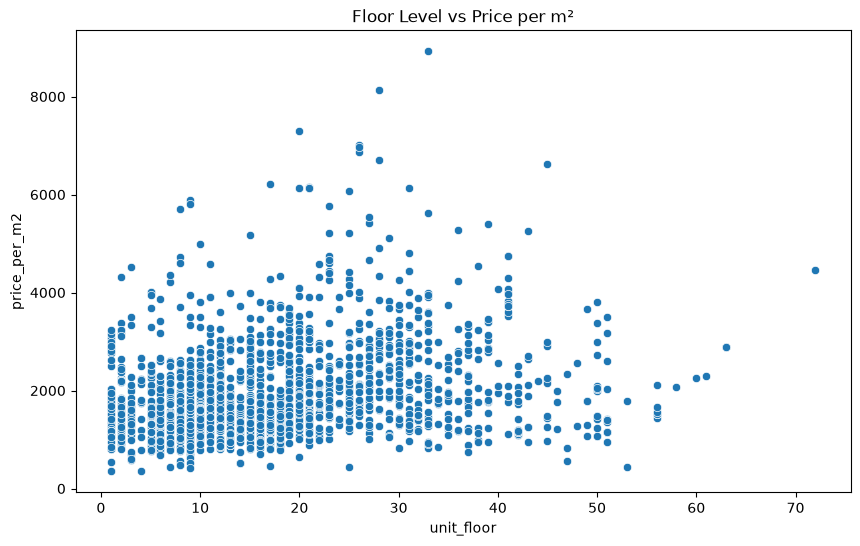

In [67]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clean_df,
    x="unit_floor",
    y="price_per_m2"
)

plt.title("Floor Level vs Price per m²")

plt.show()

Interpretation: Higher floors do not show as clear a relationship with total property price as property size does. Floor level may affect price, but other factors such as size, location and property type appear to be more important.


# Bedroom Vs Size_m2

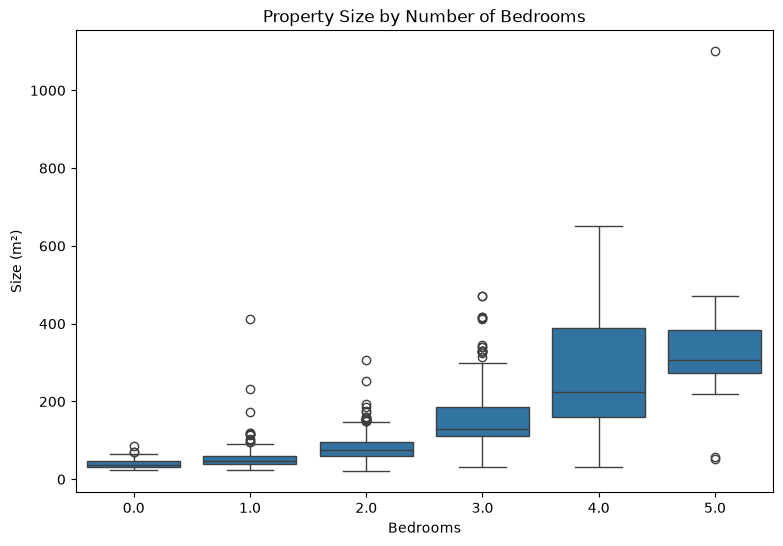

In [68]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=clean_df,
    x="bedrooms",
    y="size_m2"
)

plt.title("Property Size by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Size (m²)")

plt.show()

## PART 6 — CORRELATION ANALYSIS

## Create Correlation Matrix

In [69]:
corr_cols = [
    "price_usd",
    "size_m2",
    "price_per_m2",
    "bedrooms",
    "bathrooms",
    "unit_floor"
]

correlation = eda_df[corr_cols].corr()

correlation

,price_usd,size_m2,price_per_m2,bedrooms,bathrooms,unit_floor
price_usd,1.000000,0.858063,0.582419,0.567433,0.663046,0.266179
size_m2,0.858063,1.000000,0.296147,0.699777,0.799044,0.239799
price_per_m2,0.582419,0.296147,1.000000,0.288445,0.340272,0.262685
bedrooms,0.567433,0.699777,0.288445,1.000000,0.788008,0.215419
bathrooms,0.663046,0.799044,0.340272,0.788008,1.000000,0.232789
unit_floor,0.266179,0.239799,0.262685,0.215419,0.232789,1.000000


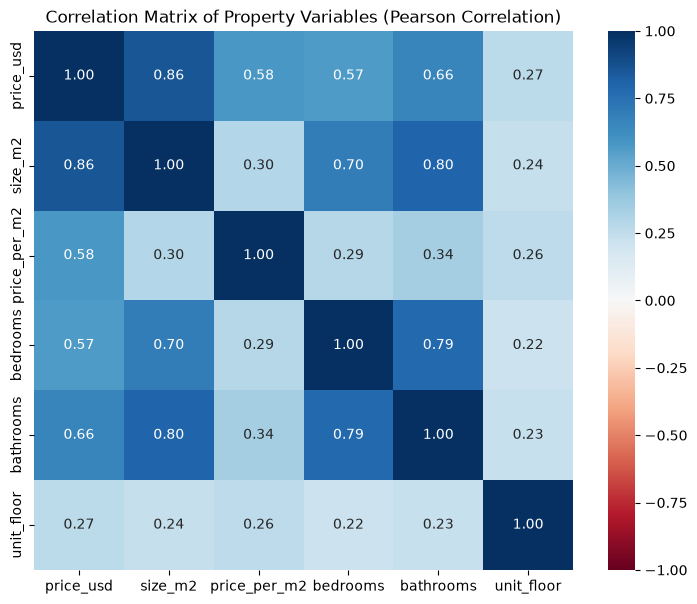

In [70]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    square=True,
    cmap="RdBu",  # <-- Add this for color
    vmin=-1,          # <-- Forces the scale minimum
    vmax=1
)

plt.title("Correlation Matrix of Property Variables (Pearson Correlation)")

plt.show()

#### Price VS Size - 0.86

Property size has a very strong positive correlation with price. Larger properties generally tend to have higher selling prices.

#### Size vs Bathrooms — 0.80

Larger properties tend to contain more bathrooms.

#### Bedrooms vs Bathrooms — 0.79

Properties with more bedrooms generally also have more bathrooms.

#### Size vs Bedrooms — 0.70

The number of bedrooms is strongly associated with property size, with larger properties generally containing more bedrooms.


#### Price vs Bathrooms — around 0.66

Property price has a strong positive relationship with the number of bathrooms. However, this may partly reflect the fact that larger properties generally contain more bathrooms.

That's better than simply saying:

More bathrooms cause higher prices.

#### Price vs Bedrooms — around 0.57

Property size has a stronger relationship with price than bedroom count does.

#### Price vs Floor — around 0.27

Higher-floor properties may sometimes cost more, but floor level by itself does not strongly explain total property price.

## Sort correlations with price

In [71]:
price_corr = (
    correlation["price_usd"]
    .sort_values(ascending=False)
)

price_corr

price_usd       1.000000
size_m2         0.858063
bathrooms       0.663046
price_per_m2    0.582419
bedrooms        0.567433
unit_floor      0.266179
Name: price_usd, dtype: float64

In [72]:
log_corr_cols = [
    "log_price_usd",
    "size_m2",
    "bedrooms",
    "bathrooms",
    "unit_floor"
]

log_corr = clean_df[log_corr_cols].corr(method="pearson")

log_corr["log_price_usd"].sort_values(ascending=False)

log_price_usd    1.000000
size_m2          0.781078
bathrooms        0.755431
bedrooms         0.722529
unit_floor       0.329376
Name: log_price_usd, dtype: float64

## Should you also use Spearman correlation?

For this dataset, I check it as an extra validation, because the prices are strongly skewed and contain valid extreme luxury listings.

Pearson measures mainly linear relationships.

Spearman looks at whether variables generally increase or decrease together based on rank.

In [73]:
spearman_corr = clean_df[corr_cols].corr(
    method="spearman"
)

spearman_corr

,price_usd,size_m2,price_per_m2,bedrooms,bathrooms,unit_floor
price_usd,1.000000,0.799530,0.715720,0.684157,0.687097,0.303890
size_m2,0.799530,1.000000,0.202865,0.789196,0.770703,0.187176
price_per_m2,0.715720,0.202865,1.000000,0.244267,0.251663,0.308104
bedrooms,0.684157,0.789196,0.244267,1.000000,0.778028,0.173746
bathrooms,0.687097,0.770703,0.251663,0.778028,1.000000,0.177210
unit_floor,0.303890,0.187176,0.308104,0.173746,0.177210,1.000000


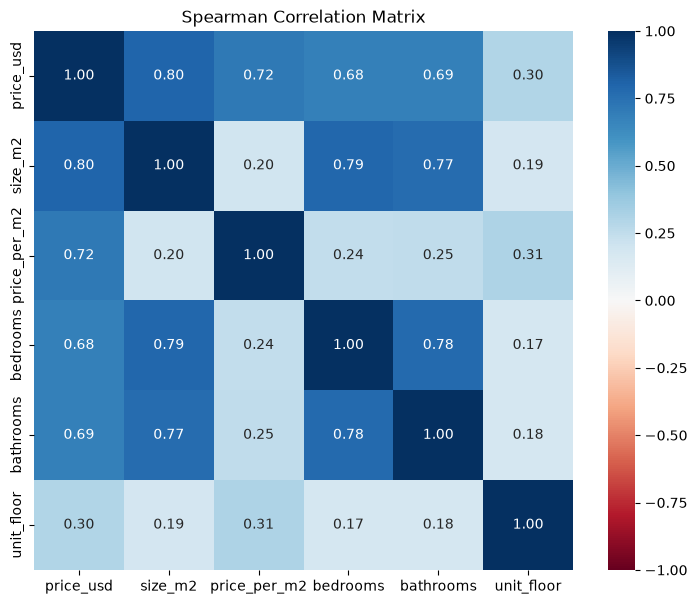

In [74]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    square=True,
    cmap="RdBu",  # <-- Add this for color
    vmin=-1,          # <-- Forces the scale minimum
    vmax=1
)

plt.title("Spearman Correlation Matrix")

plt.show()

Pearson measures a linear relationship using the original values. Spearman measures a monotonic relationship using the ranks of the values.

Both Pearson and Spearman show a strong positive association, suggesting that larger properties generally have higher prices and that the result is not driven only by a few extreme observations.

“I used Pearson as the main measure to examine linear relationships between numerical variables. Because property prices are right-skewed and the dataset contains valid luxury-property outliers, I also calculated Spearman correlation as a robustness check. Spearman is based on ranks and is less sensitive to extreme values. If both methods show similar results, I have more confidence in the relationship.”

If want me to choose only one, say:

“I would choose Pearson when the scatter plot shows an approximately linear relationship without influential outliers. I would prefer Spearman when the relationship is monotonic but not linear, or when extreme values strongly affect Pearson.”

### Correlation Analysis Findings

The correlation matrix shows that property size has the strongest
positive relationship with property price.

Price and size have a strong positive correlation, indicating that
larger properties generally have higher prices.

Bedrooms and bathrooms are also positively related to property size
and property price. Properties with more bedrooms generally tend to
be larger and contain more bathrooms.

Unit floor shows a much weaker relationship with property price,
suggesting that floor level alone does not strongly explain property
prices.

Price per square meter should be interpreted carefully because it is
derived directly from property price and size.

## Part 7: District analysis 

In [75]:
district_counts = (
    clean_df["district"]
    .value_counts(dropna=False)
)

district_counts

district
Boeung Keng Kang    559
Meanchey            416
NaN                 411
Chamkarmon          298
Toul Kork           295
Sen Sok             233
Chroy Changvar      201
Chbar Ampov          92
Daun Penh            69
Prampi Makara        49
Russey Keo           42
Pur Senchey           8
Name: count, dtype: int64

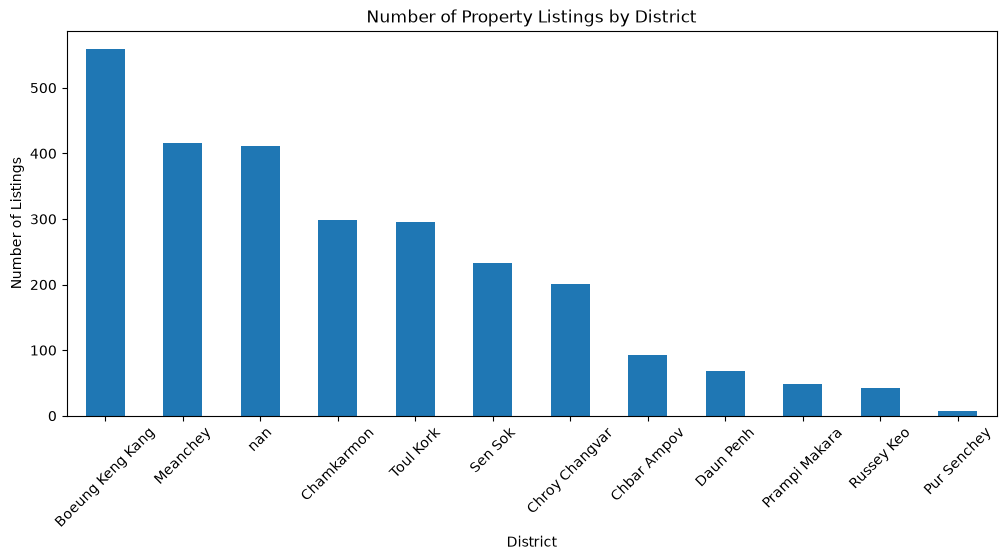

In [76]:
import matplotlib.pyplot as plt

district_counts.dropna().plot(
    kind="bar",
    figsize=(12, 5)
)

plt.xlabel("District")
plt.ylabel("Number of Listings")
plt.title("Number of Property Listings by District")
plt.xticks(rotation=45)
plt.show()

Listings are not evenly distributed across Phnom Penh districts. Some districts have substantially more properties represented than others, which should be considered when later comparing property prices between districts.

In [77]:
clean_df["district"].isna().sum()

np.int64(411)

## Median price by district

In [78]:
district_price = (
    clean_df.groupby("district")["price_usd"]
    .median()
    .sort_values(ascending=False)
)

district_price

district
Boeung Keng Kang    148688.0
Chamkarmon          134004.5
Chroy Changvar       97000.0
Russey Keo           89950.0
Prampi Makara        85000.0
Daun Penh            83000.0
Chbar Ampov          79500.0
Pur Senchey          78999.5
Toul Kork            72000.0
Sen Sok              66920.0
Meanchey             65000.0
Name: price_usd, dtype: float64

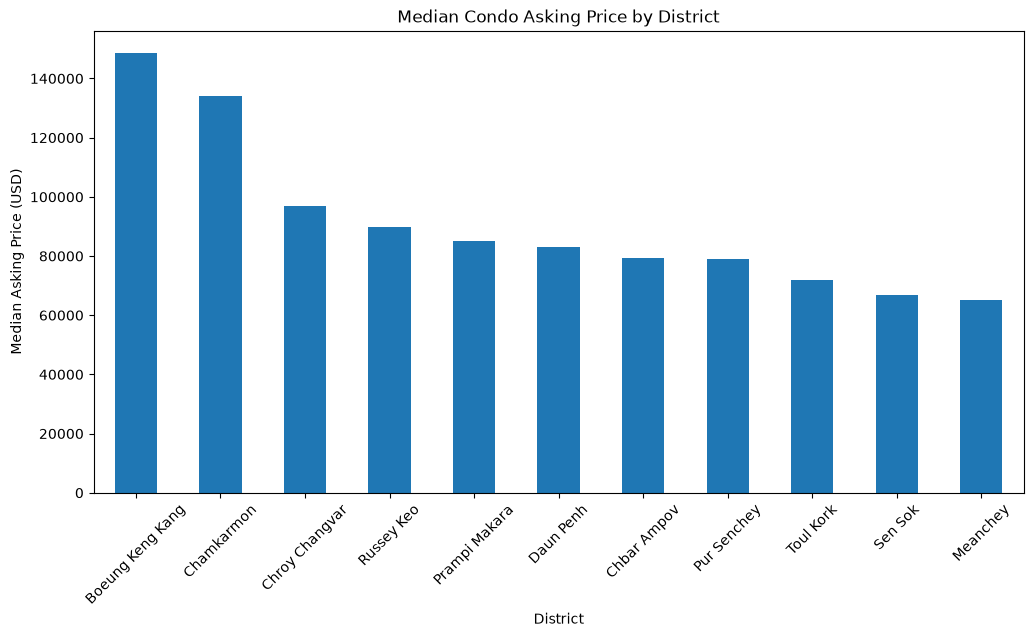

In [79]:
district_price.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("District")
plt.ylabel("Median Asking Price (USD)")
plt.title("Median Condo Asking Price by District")
plt.xticks(rotation=45)
plt.show()

The median asking price differs noticeably across districts. Some districts contain generally more expensive condo listings than others, suggesting that location may be an important factor in property price.

Why median instead of mean?

Because your price distribution contains luxury properties.

Imagine one district has:

$70K
$80K
$90K
$100K
$5M

That $5M property can strongly increase the mean.

Median is much more resistant to that.

So for real-estate EDA:

Median price is often easier to interpret than mean price.

But district price has one problem

Suppose:

District A
Median price = $300K

District B
Median price = $100K

Can we immediately say District A is more expensive?

Not necessarily.

Maybe District A contains mostly:

150 m² penthouses

while District B contains mostly:

50 m² condos

That's why our next analysis is even more useful.

## Median price per m² by district

Higher median price does not automatically mean the district is more expensive per square meter.

In [80]:
district_ppm2 = (
    clean_df.groupby("district")["price_per_m2"]
    .median()
    .sort_values(ascending=False)
)

district_ppm2

district
Boeung Keng Kang    2200.000
Daun Penh           2000.000
Chamkarmon          1978.165
Chbar Ampov         1813.825
Russey Keo          1522.165
Chroy Changvar      1511.110
Sen Sok             1458.000
Prampi Makara       1428.570
Toul Kork           1375.000
Meanchey            1289.515
Pur Senchey         1164.525
Name: price_per_m2, dtype: float64

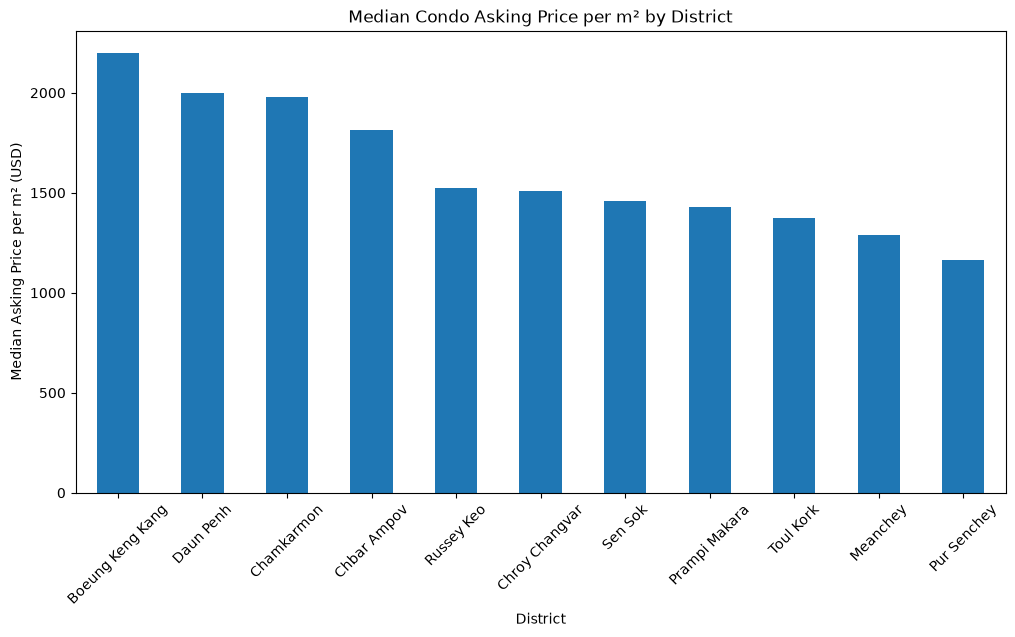

In [81]:
district_ppm2.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("District")
plt.ylabel("Median Asking Price per m² (USD)")
plt.title("Median Condo Asking Price per m² by District")
plt.xticks(rotation=45)
plt.show()

Why price_per_m2 is useful here

Consider:

Condo A
$100,000
50 m²

Price/m² = $2,000

and:

Condo B
$150,000
100 m²

Price/m² = $1,500

Although Condo B has a higher total price:

$150,000 > $100,000

Condo A is actually more expensive per square meter:

$2,000/m² > $1,500/m²

So price_per_m2 makes district comparison fairer.

## Add number of listings beside the district statistics

In [82]:
district_summary = (
    clean_df.groupby("district")
    .agg(
        listings=("listing_id", "count"),
        median_price=("price_usd", "median"),
        median_size=("size_m2", "median"),
        median_price_per_m2=("price_per_m2", "median")
    )
    .sort_values(
        "median_price_per_m2",
        ascending=False
    )
)

district_summary

,listings,median_price,median_size,median_price_per_m2
district,,,,
Boeung Keng Kang,559,148688.0,69.00,2200.000
Daun Penh,69,83000.0,40.97,2000.000
Chamkarmon,298,134004.5,65.00,1978.165
Chbar Ampov,92,79500.0,45.50,1813.825
Russey Keo,42,89950.0,55.00,1522.165
Chroy Changvar,201,97000.0,66.00,1511.110
Sen Sok,233,66920.0,49.00,1458.000
Prampi Makara,49,85000.0,55.00,1428.570
Toul Kork,295,72000.0,52.00,1375.000


## Filter districts with very few listings

In [83]:
district_summary_filtered = (
    district_summary[
        district_summary["listings"] >= 20
    ]
)

district_summary_filtered

,listings,median_price,median_size,median_price_per_m2
district,,,,
Boeung Keng Kang,559,148688.0,69.00,2200.000
Daun Penh,69,83000.0,40.97,2000.000
Chamkarmon,298,134004.5,65.00,1978.165
Chbar Ampov,92,79500.0,45.50,1813.825
Russey Keo,42,89950.0,55.00,1522.165
Chroy Changvar,201,97000.0,66.00,1511.110
Sen Sok,233,66920.0,49.00,1458.000
Prampi Makara,49,85000.0,55.00,1428.570
Toul Kork,295,72000.0,52.00,1375.000


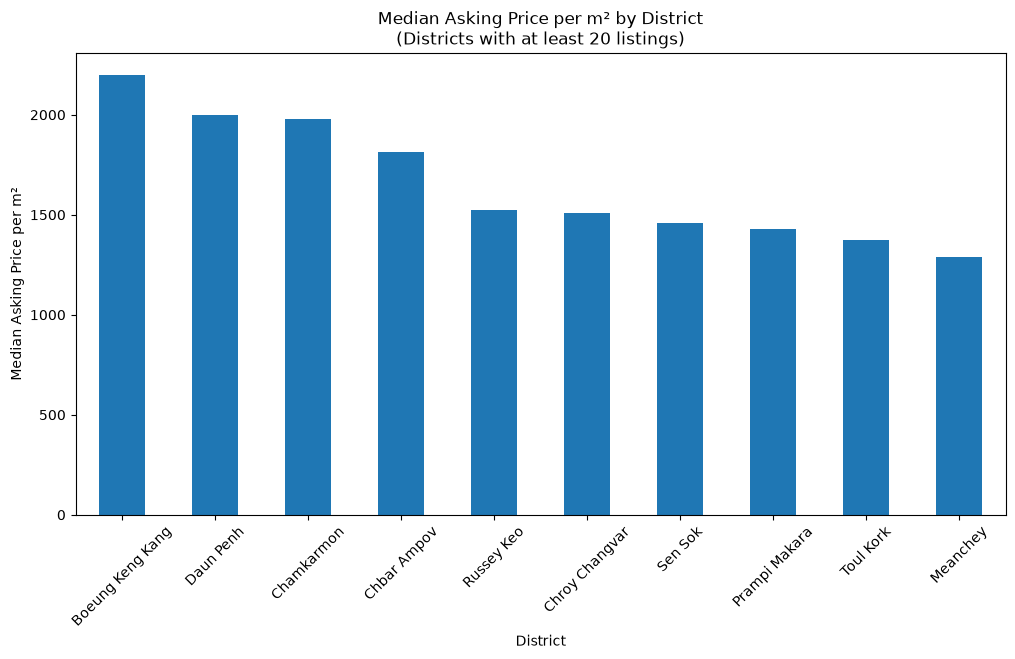

In [84]:
district_summary_filtered[
    "median_price_per_m2"
].sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("District")
plt.ylabel("Median Asking Price per m²")
plt.title(
    "Median Asking Price per m² by District\n"
    "(Districts with at least 20 listings)"
)
plt.xticks(rotation=45)
plt.show()

## Boxplot: District vs Price

<Figure size 1400x700 with 0 Axes>

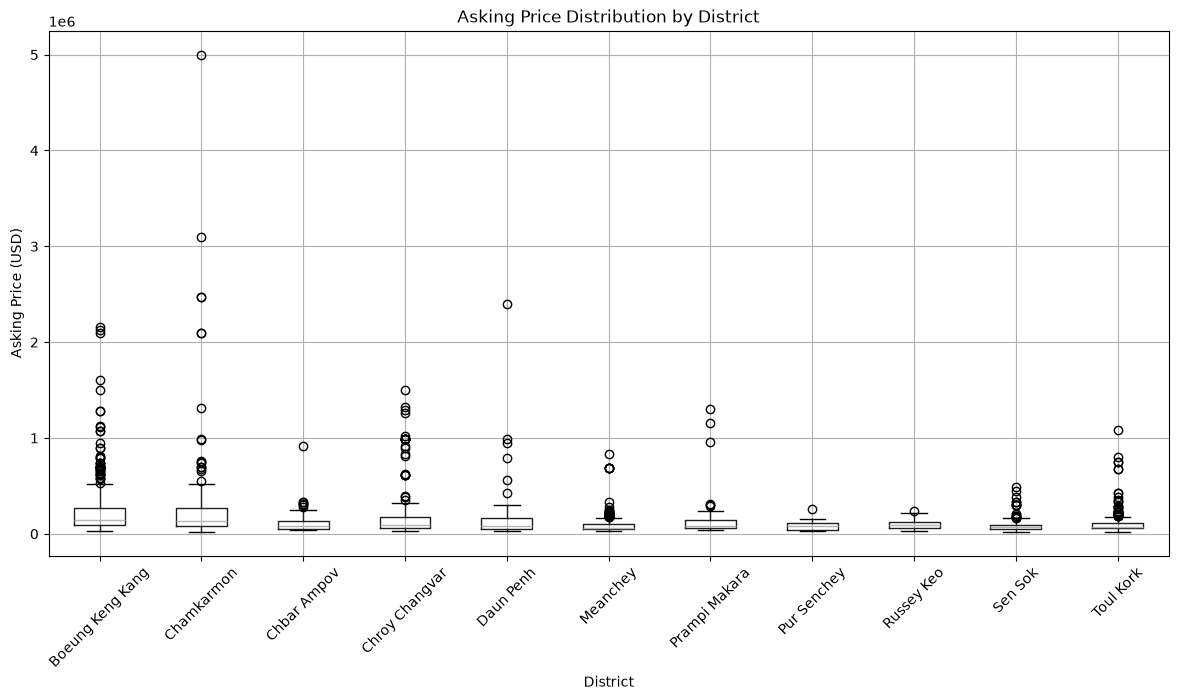

In [85]:
district_order = (
    clean_df.groupby("district")["price_usd"]
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(14, 7))

clean_df.boxplot(
    column="price_usd",
    by="district",
    figsize=(14, 7),
    rot=45
)

plt.title("Asking Price Distribution by District")
plt.suptitle("")
plt.xlabel("District")
plt.ylabel("Asking Price (USD)")
plt.show()

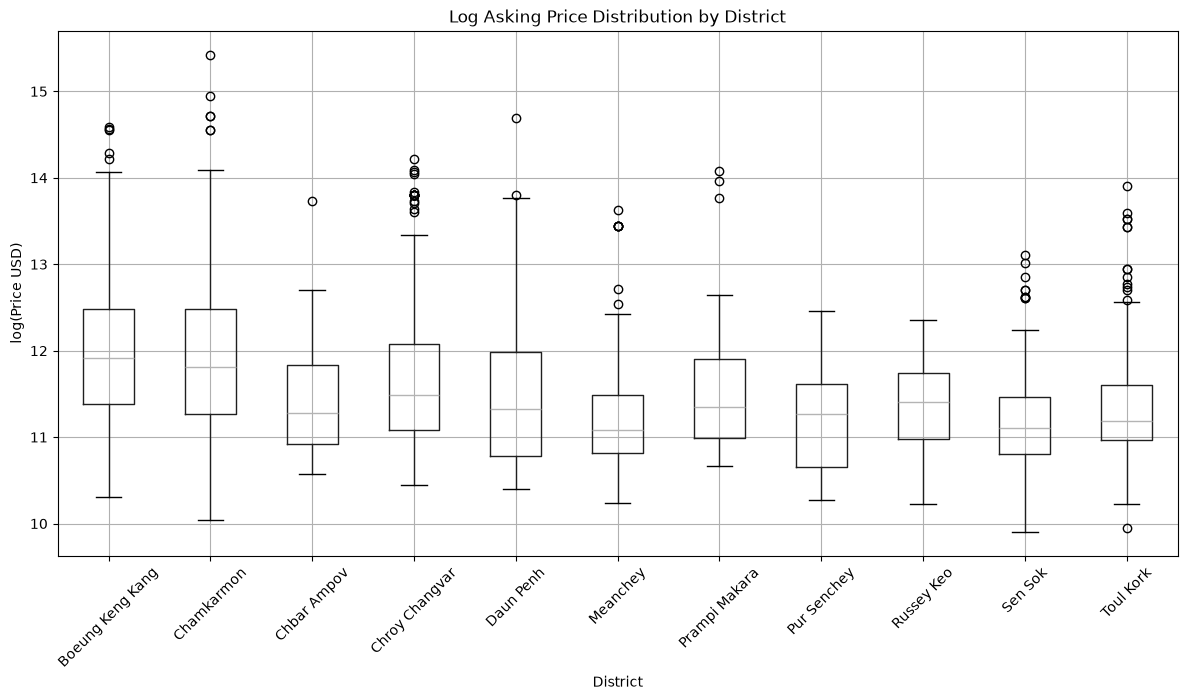

In [86]:
clean_df.boxplot(
    column="log_price_usd",
    by="district",
    figsize=(14, 7),
    rot=45
)

plt.title("Log Asking Price Distribution by District")
plt.suptitle("")
plt.xlabel("District")
plt.ylabel("log(Price USD)")
plt.show()

In [87]:
district_summary = (
    clean_df.groupby("district")
    .agg(
        listings=("listing_id", "count"),
        median_price=("price_usd", "median"),
        median_size=("size_m2", "median"),
        median_price_per_m2=("price_per_m2", "median")
    )
    .sort_values(
        "median_price_per_m2",
        ascending=False
    )
)

district_summary

,listings,median_price,median_size,median_price_per_m2
district,,,,
Boeung Keng Kang,559,148688.0,69.00,2200.000
Daun Penh,69,83000.0,40.97,2000.000
Chamkarmon,298,134004.5,65.00,1978.165
Chbar Ampov,92,79500.0,45.50,1813.825
Russey Keo,42,89950.0,55.00,1522.165
Chroy Changvar,201,97000.0,66.00,1511.110
Sen Sok,233,66920.0,49.00,1458.000
Prampi Makara,49,85000.0,55.00,1428.570
Toul Kork,295,72000.0,52.00,1375.000


When I compared condo listings across districts, Boeung Keng Kang had the highest median asking price per square meter at around $2,200, followed by Daun Penh and Chamkarmon. Districts such as Meanchey and Toul Kork had lower median prices per square meter. This suggests that location has an important relationship with condo asking prices.

# Part 8: Property Type Analysis

In [88]:
clean_df["property_type"].value_counts(dropna=False)

property_type
Condo        2482
Penthouse     191
Name: count, dtype: int64

In [89]:
# create a summary table

property_type_summary = (
    clean_df.groupby("property_type")
    .agg(
        listings=("listing_id", "count"),
        median_price=("price_usd", "median"),
        median_size=("size_m2", "median"),
        median_price_per_m2=("price_per_m2", "median"),
        median_bedrooms=("bedrooms", "median"),
        median_bathrooms=("bathrooms", "median"),
        median_floor=("unit_floor", "median")
    )
)

property_type_summary

,listings,median_price,median_size,median_price_per_m2,median_bedrooms,median_bathrooms,median_floor
property_type,,,,,,,
Condo,2482,90000.0,58.0,1582.395,1.0,1.0,15.0
Penthouse,191,275000.0,152.0,2620.000,3.0,2.0,23.0


## Compare median asking price

In [90]:
property_price = (
    df.groupby("property_type")["price_usd"]
    .median()
    .sort_values(ascending=False)
)

property_price

property_type
Penthouse    275000.0
Condo         90000.0
Name: price_usd, dtype: float64

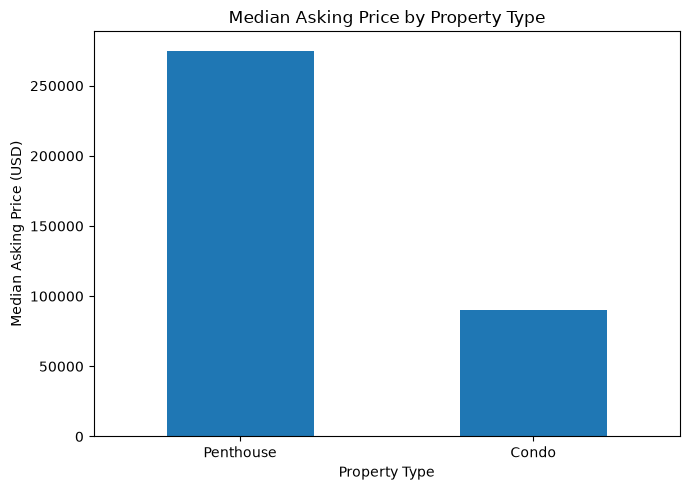

In [91]:
property_price.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.xlabel("Property Type")
plt.ylabel("Median Asking Price (USD)")
plt.title("Median Asking Price by Property Type")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Compare median size

In [92]:
property_size = (
    clean_df.groupby("property_type")["size_m2"]
    .median()
    .sort_values(ascending=False)
)

property_size

property_type
Penthouse    152.0
Condo         58.0
Name: size_m2, dtype: float64

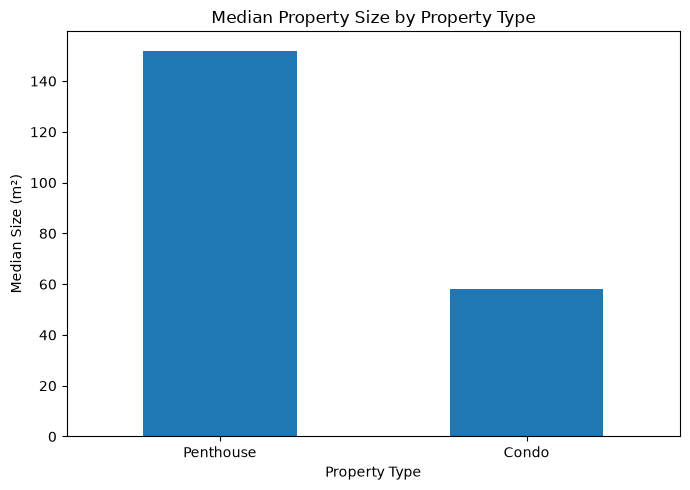

In [93]:
property_size.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.xlabel("Property Type")
plt.ylabel("Median Size (m²)")
plt.title("Median Property Size by Property Type")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Compare price per square meter

In [94]:
property_ppm2 = (
    clean_df.groupby("property_type")["price_per_m2"]
    .median()
    .sort_values(ascending=False)
)

property_ppm2

property_type
Penthouse    2620.000
Condo        1582.395
Name: price_per_m2, dtype: float64

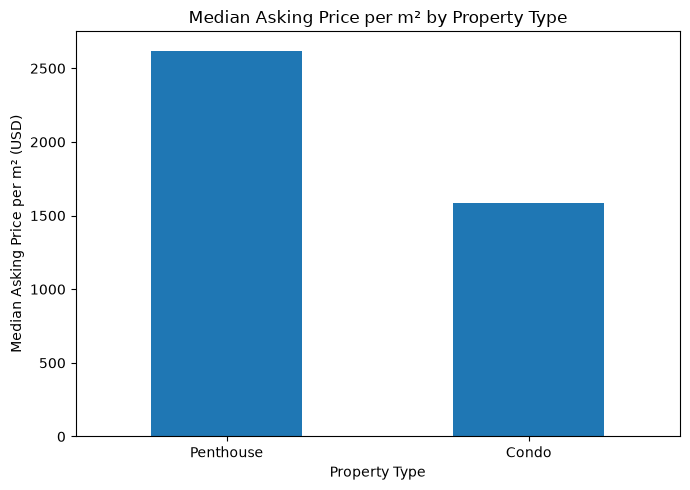

In [95]:
property_ppm2.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.xlabel("Property Type")
plt.ylabel("Median Asking Price per m² (USD)")
plt.title("Median Asking Price per m² by Property Type")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

This tells you whether penthouses are not just more expensive overall, but also more expensive for each square meter.

For example:

Condo
Median price = $90,000
Median size  = 55 m²
Median $/m²  = $1,600

Penthouse
Median price = $400,000
Median size  = 200 m²
Median $/m²  = $2,000

Then you could say:

Penthouses are typically larger and have higher total asking prices, and they also command a somewhat higher asking price per square meter.

## Boxplot: property type vs price

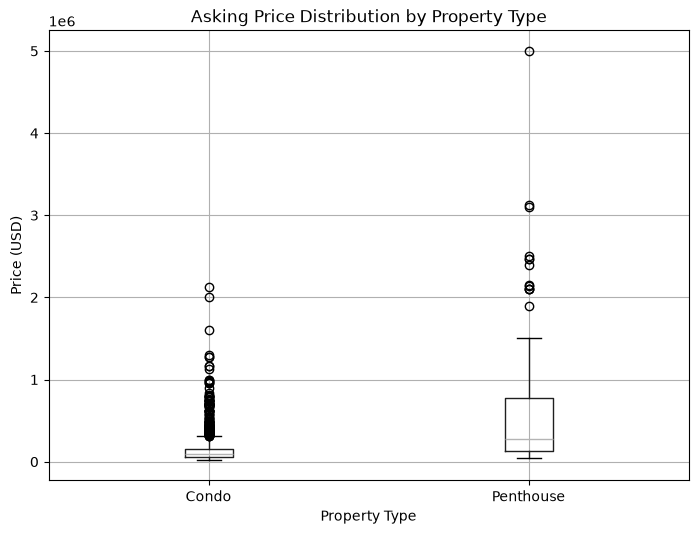

In [96]:
clean_df.boxplot(
    column="price_usd",
    by="property_type",
    figsize=(8, 6)
)

plt.title("Asking Price Distribution by Property Type")
plt.suptitle("")
plt.xlabel("Property Type")
plt.ylabel("Price (USD)")
plt.show()

In [97]:
import numpy as np

if "log_price_usd" not in clean_df.columns:
    clean_df["log_price_usd"] = np.log1p(
        clean_df["price_usd"]
    )

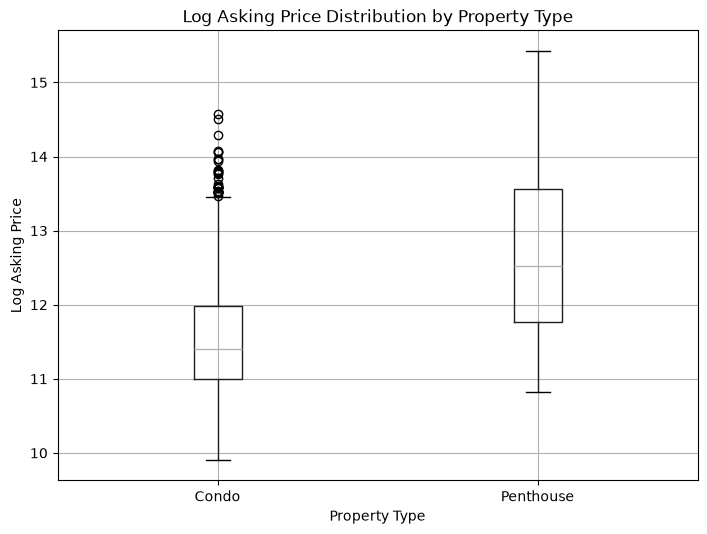

In [98]:
clean_df.boxplot(
    column="log_price_usd",
    by="property_type",
    figsize=(8, 6)
)

plt.title("Log Asking Price Distribution by Property Type")
plt.suptitle("")
plt.xlabel("Property Type")
plt.ylabel("Log Asking Price")
plt.show()

## Compare bedrooms and bathrooms

In [99]:
clean_df.groupby("property_type")[
    ["bedrooms", "bathrooms"]
].median()

,bedrooms,bathrooms
property_type,,
Condo,1.0,1.0
Penthouse,3.0,2.0


Property type shows a clear relationship with condo asking prices. Penthouses have substantially higher median asking prices, larger median floor areas, more bedrooms and bathrooms, and higher median asking prices per square meter than standard condos. This suggests that property type should be retained as a feature for price prediction.

## PART 9 — DATA SOURCE ANALYSIS

## Number of listings by source

## Source Summary

In [100]:
source_summary = (
    clean_df.groupby("source")
    .agg(
        listings=("listing_id", "count"),
        median_price=("price_usd", "median"),
        median_size=("size_m2", "median"),
        median_price_per_m2=("price_per_m2", "median")
    )
    .sort_values(
        "median_price_per_m2",
        ascending=False
    )
)

source_summary

,listings,median_price,median_size,median_price_per_m2
source,,,,
camrealtyservice.com,199,162000.0,65.0,2430.090
aps.com.kh,109,165000.0,75.0,2160.490
realestate.com.kh,844,91000.0,55.0,1651.085
harbor-property.com,753,96012.0,61.0,1520.000
khpropertyhub.com,675,85000.0,57.0,1506.670
khmer24.com,93,85000.0,67.0,1417.910


The distribution of property listings differs across data sources.

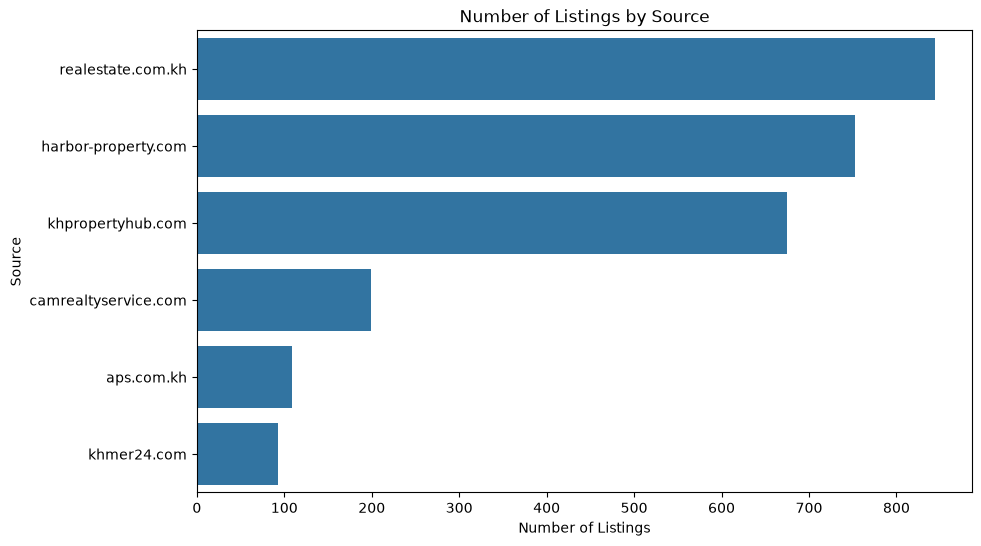

In [101]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=clean_df,
    y="source",
    order=clean_df["source"].value_counts().index
)

plt.title("Number of Listings by Source")
plt.xlabel("Number of Listings")
plt.ylabel("Source")

plt.show()

The dataset is not equally distributed across sources. realestate.com.kh, harbor-property.com, and khpropertyhub.com contribute most of the listings, while APS and Khmer24 contribute much fewer records.

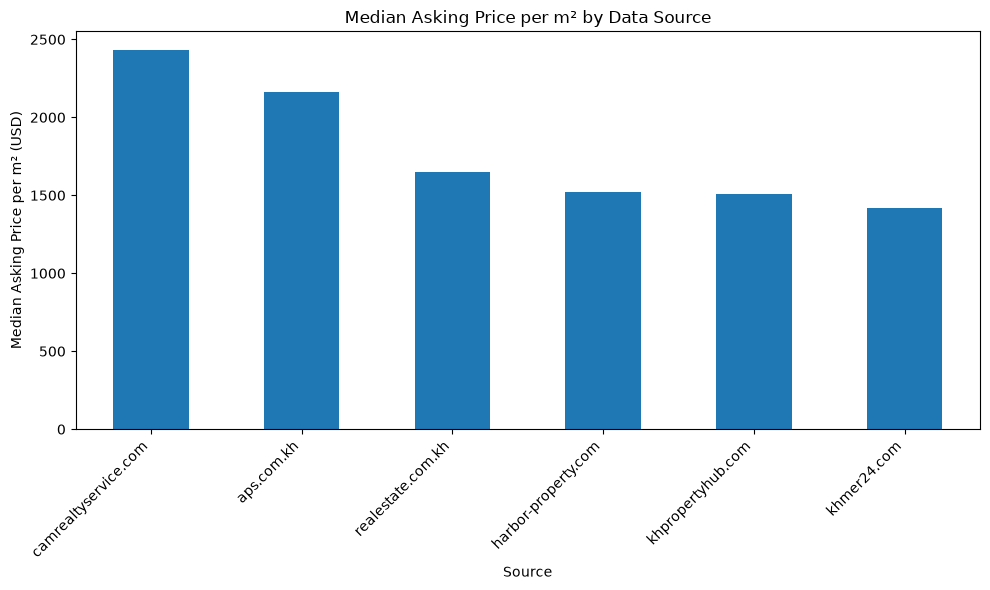

In [102]:
source_ppm2 = (
    source_summary[
        "median_price_per_m2"
    ]
    .sort_values(
        ascending=False
    )
)

source_ppm2.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Source")
plt.ylabel("Median Asking Price per m² (USD)")
plt.title(
    "Median Asking Price per m² by Data Source"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

“The listing sources show different price distributions. CamRealtyService and APS contain listings with higher median asking prices per square meter, while Khmer24 has the lowest. This suggests that each website may target different property segments, so I use source mainly for data-quality and bias analysis rather than as a direct pricing factor.”

## Check data coverage by source

In [103]:
coverage_cols = [
    "bedrooms",
    "bathrooms",
    "unit_floor",
    "price_usd",
    "size_m2",
    "district",
    "commune",
    "listing_created_at"
]

In [104]:
source_coverage = (
    clean_df
    .groupby("source")[coverage_cols]
    .apply(lambda x: x.notna().mean() * 100)
    .round(1)
)

source_coverage

,bedrooms,bathrooms,unit_floor,price_usd,size_m2,district,commune,listing_created_at
source,,,,,,,,
aps.com.kh,100.0,3.7,91.7,100.0,100.0,75.2,0.0,0.0
camrealtyservice.com,100.0,100.0,83.4,100.0,100.0,14.1,2.5,0.0
harbor-property.com,98.7,86.5,57.2,100.0,100.0,71.7,100.0,0.0
khmer24.com,86.0,32.3,47.3,100.0,100.0,100.0,0.0,0.0
khpropertyhub.com,79.1,40.9,79.4,100.0,100.0,100.0,0.0,0.0
realestate.com.kh,99.1,94.8,92.3,100.0,100.0,100.0,99.8,100.0


aps.com.kh
Bathrooms = 3.7%

That means:

Only about 4 out of every 100 APS listings provide bathroom information.

That's extremely low.

But:

camrealtyservice.com
Bathrooms = 100%

means:

Every collected CamRealty listing has bathroom information.

So bathroom missingness depends heavily on the source.

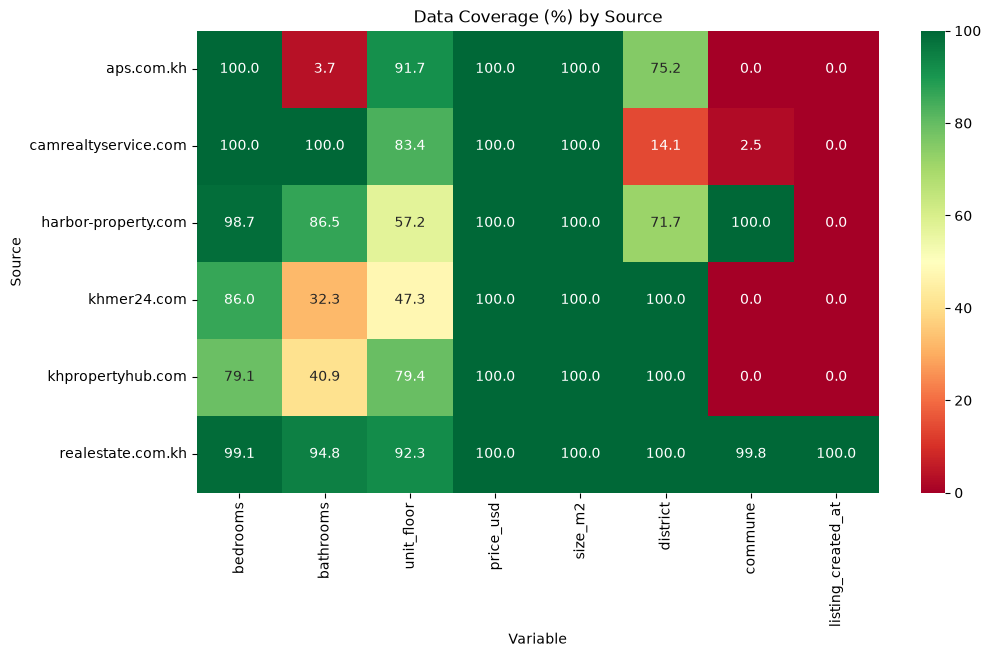

In [105]:
plt.figure(figsize=(11, 6))

sns.heatmap(
    source_coverage,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",  # <-- Add this for color
    vmin=0,          # <-- Forces the scale minimum
    vmax=100
)

plt.title("Data Coverage (%) by Source")
plt.xlabel("Variable")
plt.ylabel("Source")

plt.show()

How to explain the heatmap

The heatmap shows substantial differences in data completeness across websites. Realestate.com.kh has high coverage for most important variables, while some sources have poor coverage for particular fields. For example, APS has very low bathroom coverage, and CamRealty has very low district coverage.

## Outlier Investigation

#### Get descriptive statistics

In [106]:
clean_df[
    [
        "price_usd",
        "size_m2",
        "price_per_m2"
    ]
].describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99
    ]
).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
price_usd,2673.0,170818.361766,259363.900292,20000.00,30000.0000,39860.00,62000.0,95000.00,180000.00,520000.000,1.266888e+06,5000000.00
size_m2,2673.0,80.224403,69.469563,20.00,25.0000,30.33,43.0,60.00,91.00,199.312,4.022400e+02,1100.00
price_per_m2,2673.0,1888.936150,937.472751,303.95,690.4704,918.37,1250.0,1622.22,2283.46,3670.952,5.295319e+03,8919.53


#### Make boxplots

##### Price

C:\Users\Meng\AppData\Local\Temp\ipykernel_3264\1432327930.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


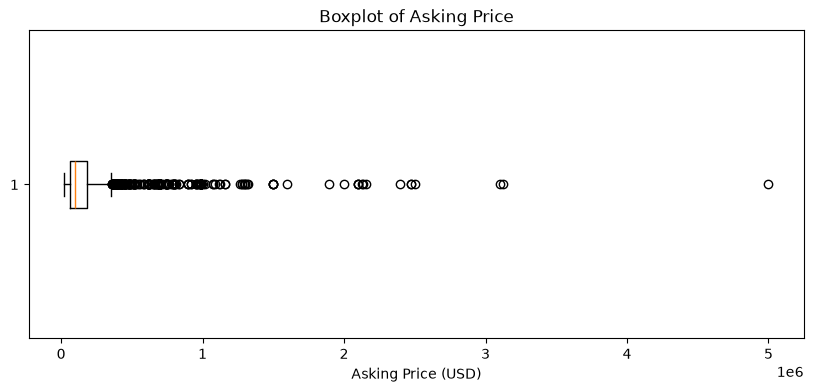

In [107]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    clean_df["price_usd"].dropna(),
    vert=False
)

plt.xlabel("Asking Price (USD)")
plt.title("Boxplot of Asking Price")

plt.show()

##### Size

C:\Users\Meng\AppData\Local\Temp\ipykernel_3264\4104560754.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


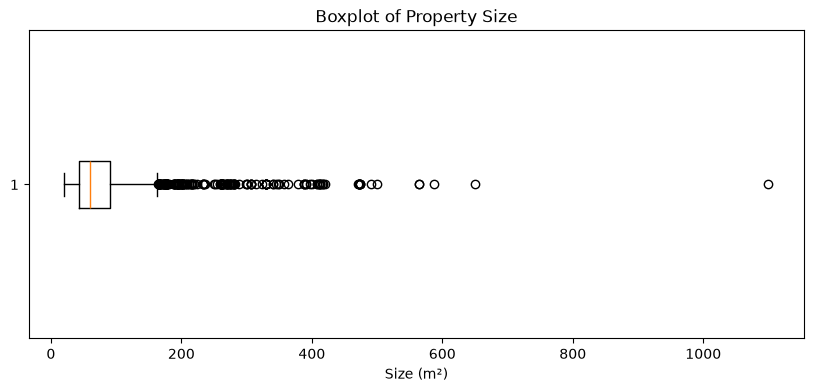

In [108]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    clean_df["size_m2"].dropna(),
    vert=False
)

plt.xlabel("Size (m²)")
plt.title("Boxplot of Property Size")

plt.show()

##### Price/m2

C:\Users\Meng\AppData\Local\Temp\ipykernel_3264\1114722117.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


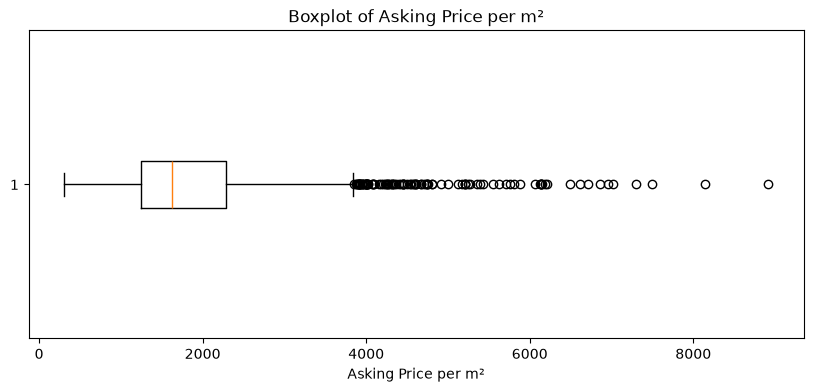

In [109]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    clean_df["price_per_m2"].dropna(),
    vert=False
)

plt.xlabel("Asking Price per m²")
plt.title("Boxplot of Asking Price per m²")

plt.show()

#### Count the outlier

In [110]:
def iqr_outlier_info(clean_df, column):
    q1 = clean_df[column].quantile(0.25)
    q3 = clean_df[column].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = clean_df[
        (clean_df[column] < lower) |
        (clean_df[column] > upper)
    ]

    print(f"{column}")
    print(f"Q1          : {q1:,.2f}")
    print(f"Q3          : {q3:,.2f}")
    print(f"IQR         : {iqr:,.2f}")
    print(f"Lower bound : {lower:,.2f}")
    print(f"Upper bound : {upper:,.2f}")
    print(f"Outliers    : {len(outliers):,}")
    print(
        f"Percentage  : "
        f"{len(outliers) / len(df) * 100:.2f}%"
    )
    print("-" * 40)

In [111]:
for col in [
    "price_usd",
    "size_m2",
    "price_per_m2"
]:
    iqr_outlier_info(clean_df, col)

price_usd
Q1          : 62,000.00
Q3          : 180,000.00
IQR         : 118,000.00
Lower bound : -115,000.00
Upper bound : 357,000.00
Outliers    : 224
Percentage  : 8.38%
----------------------------------------
size_m2
Q1          : 43.00
Q3          : 91.00
IQR         : 48.00
Lower bound : -29.00
Upper bound : 163.00
Outliers    : 201
Percentage  : 7.52%
----------------------------------------
price_per_m2
Q1          : 1,250.00
Q3          : 2,283.46
IQR         : 1,033.46
Lower bound : -300.19
Upper bound : 3,833.65
Outliers    : 104
Percentage  : 3.89%
----------------------------------------


#### Inspect the extreme records

In [112]:
columns_to_show = [
    "listing_id",
    "title",
    "property_type",
    "district",
    "price_usd",
    "size_m2",
    "price_per_m2",
    "bedrooms",
    "bathrooms",
    "unit_floor",
    "source"
]

##### Price

In [113]:
clean_df.nlargest(
    5,
    "price_usd"
)[columns_to_show]

,listing_id,title,property_type,district,price_usd,size_m2,price_per_m2,bedrooms,bathrooms,unit_floor,source
2665,harbor-property.com_86231,"Condo for Sale, Tonle Bassac, $5000000_5Bedroo...",Penthouse,Chamkarmon,5000000.0,1100.00,4545.45,5.0,5.0,38.0,harbor-property.com
2668,camrealtyservice.com_sky-villa-for-sale-in-mor...,45th Floor 5 Bedroom Sky Villa For Sale in Mor...,Penthouse,NaN,3121250.0,471.66,6617.58,5.0,6.0,45.0,camrealtyservice.com
2666,camrealtyservice.com_36th-floor-luxurious-4-be...,36th Floor Luxurious 4 Bedroom Penthouse For S...,Penthouse,Chamkarmon,3100000.0,588.00,5272.11,4.0,5.0,36.0,camrealtyservice.com
2669,camrealtyservice.com_duplex-condo-for-sale-the...,25th Floor 3 Bedroom Duplex Condo For Sale The...,Penthouse,NaN,2500000.0,412.00,6067.96,3.0,3.0,25.0,camrealtyservice.com
2660,harbor-property.com_96084,"Condo for Sale, Tonle Bassac, $2470000_4Bedroo...",Penthouse,Chamkarmon,2470000.0,474.00,5210.97,4.0,4.0,NaN,harbor-property.com


In [114]:
clean_df.nlargest(
    5,
    "size_m2"
)[columns_to_show]

,listing_id,title,property_type,district,price_usd,size_m2,price_per_m2,bedrooms,bathrooms,unit_floor,source
2665,harbor-property.com_86231,"Condo for Sale, Tonle Bassac, $5000000_5Bedroo...",Penthouse,Chamkarmon,5000000.0,1100.00,4545.45,5.0,5.0,38.0,harbor-property.com
2671,aps.com.kh_penthouse-4-bedroom-condo-for-sale-...,Penthouse 4 Bedroom Condo For Sale - De Castle...,Penthouse,Boeung Keng Kang,1500000.0,650.00,2307.69,4.0,NaN,32.0,aps.com.kh
2666,camrealtyservice.com_36th-floor-luxurious-4-be...,36th Floor Luxurious 4 Bedroom Penthouse For S...,Penthouse,Chamkarmon,3100000.0,588.00,5272.11,4.0,5.0,36.0,camrealtyservice.com
2657,khpropertyhub.com_21462,[Fully Furnished] 4-BR Penthouse of 564 Sq.m. ...,Penthouse,Daun Penh,2395000.0,564.00,4246.45,4.0,NaN,30.0,khpropertyhub.com
2662,harbor-property.com_114384,"Condo for Sale, Phsar Thmey I, $2000000_4Bedro...",Condo,NaN,2000000.0,563.75,3547.67,4.0,5.0,NaN,harbor-property.com


In [115]:
clean_df.nlargest(
    20,
    "price_per_m2"
)[columns_to_show]

,listing_id,title,property_type,district,price_usd,size_m2,price_per_m2,bedrooms,bathrooms,unit_floor,source
1703,harbor-property.com_112270,"Condo for Sale, BKK1, $285425_4Bedroom_32m²",Condo,Boeung Keng Kang,285425.0,32.00,8919.53,4.0,4.0,33.0,harbor-property.com
1707,harbor-property.com_115177,"Condo for Sale, Chroy Chongva, $228000_2Bedroo...",Condo,NaN,228000.0,28.00,8142.86,2.0,2.0,28.0,harbor-property.com
1986,harbor-property.com_113115,"Condo for Sale, Boeung Kak II, $150000_2Bedroo...",Condo,Toul Kork,150000.0,20.00,7500.00,2.0,2.0,NaN,harbor-property.com
1985,harbor-property.com_113116,"Condo for Sale, Phnom Penh, $270000_2Bedroom_37m²",Condo,NaN,270000.0,37.00,7297.30,2.0,3.0,20.0,harbor-property.com
2661,harbor-property.com_114877,"Condo for Sale, BKK1, $2153387_5Bedroom_306.86m²",Penthouse,Boeung Keng Kang,2153387.0,306.86,7017.49,5.0,4.0,26.0,harbor-property.com
2667,camrealtyservice.com_picasso-sky-garden-s10731...,Duplex 5 Bedroom Penthouse For Sale in Picasso...,Penthouse,NaN,2136378.0,306.86,6962.06,5.0,4.0,26.0,camrealtyservice.com
2656,realestate.com.kh_220195,Luxury Penthouse For Sale in BKK Area,Penthouse,Boeung Keng Kang,2100000.0,306.00,6862.75,5.0,4.0,26.0,realestate.com.kh
2417,camrealtyservice.com_picasso-sky-garden-s11111...,4 Bedroom Duplex Penthouse For Sale in Picasso...,Penthouse,NaN,1500000.0,223.39,6714.71,4.0,4.0,28.0,camrealtyservice.com
2668,camrealtyservice.com_sky-villa-for-sale-in-mor...,45th Floor 5 Bedroom Sky Villa For Sale in Mor...,Penthouse,NaN,3121250.0,471.66,6617.58,5.0,6.0,45.0,camrealtyservice.com
1496,khpropertyhub.com_12966,Condo for sale/rent,Condo,Daun Penh,201197.0,31.00,6490.23,NaN,NaN,NaN,khpropertyhub.com


## Conclusion:
The EDA shows that property price is strongly related to property size, while bedrooms and bathrooms also show positive relationships with price. Unit floor has a weaker relationship with price. Penthouses are generally larger and more expensive than condos. Property prices and price per square meter vary across districts, with some central areas showing higher values. The analysis also found important source-related data-quality differences, especially for bathrooms, floor, district, and commune information. Because missing values and listing composition differ across websites, results should be interpreted with consideration of source bias.

## Limitations:

. Some columns contain many missing values.

. The dataset comes from multiple websites with different data structures.

. Some scraped values may contain source or parsing errors.

. The data represents property listings, not completed property transactions.

. Some districts and property categories have much smaller sample sizes than others.

# Final EDA Findings

1. Dataset quality and coverage. The final Gold dataset contains 2,673 unique property listings collected from six real-estate websites. Bedrooms have 93.6% coverage, district 84.6%, unit floor 77.0%, and bathrooms 73.3%. Project name coverage is relatively low at 16.4%, while latitude and longitude are currently unavailable.

2. Asking price is strongly right-skewed. The median asking price is approximately $95,000, while the mean is approximately $170,818. The large difference between mean and median shows that a relatively small number of expensive luxury properties create a long upper tail. Because of this distribution, log_price_usd is more suitable as the modeling target than raw price alone.

3. Property size has the strongest relationship with asking price. size_m2 has a Pearson correlation of 0.86 and a Spearman correlation of 0.80 with price_usd. Bedrooms and bathrooms also show meaningful positive relationships with price, while floor level has a much weaker relationship.

4. Some numeric features are related to each other. Size, bedrooms, and bathrooms are strongly correlated because larger properties generally contain more rooms. This may create multicollinearity for Linear Regression, although it is less problematic for tree-based models such as Random Forest and XGBoost.

5. Location shows a strong pricing pattern. Boeung Keng Kang has the highest median asking price per square meter at approximately $2,200/m², followed by Daun Penh at around $2,000/m² and Chamkarmon at approximately $1,978/m². This indicates that district should be an important categorical feature in the prediction model.

6. Penthouses form a distinct premium segment. Standard condos have a median asking price of approximately $90,000, median size of 58 m², and median price per square meter of about $1,582. Penthouses have a much higher median asking price of approximately $275,000, median size of 152 m², and median price per square meter of approximately $2,620. Therefore, property_type should be retained as a model feature.

7. Listing distributions differ across websites. CamRealtyService has the highest median asking price per square meter at approximately $2,430/m², while Khmer24 has the lowest at approximately $1,418/m². This suggests that different websites may focus on different market segments. source is useful for bias analysis, but it should not necessarily be used as a main property-price predictor.

8. Outliers are present but are not automatically removed. Using the IQR rule, about 8.38% of asking prices, 7.52% of property sizes, and 3.89% of price-per-square-meter values are statistical outliers. Real-estate datasets naturally contain luxury condos and penthouses, so statistical outliers can represent legitimate properties. For this project, the dataset is therefore retained at 2,673 rows, and outliers are handled through transformations and robust modeling rather than blanket deletion.